# Gradient Boosting (Classification & Regression)

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with Scikit-learn](#6-implementation-with-scikit-learn)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)

> **Scope**: the from-scratch twin in `src/models/ensemble_models.py` implements the **classifier** only (`GradientBoostingClassifierScratch`: binary log-loss and multiclass softmax deviance). Regression with `GradientBoostingRegressor` is shown in §6 using scikit-learn only.

---

## 1. Introduction

**Gradient boosting** builds a strong model by making a sequence of *small* improvements. Each stage fits a small regression tree to what the current ensemble still gets wrong — the residuals — and adds that correction to the prediction, scaled down by a learning rate $\nu$:

$$F_m(x) = F_{m-1}(x) + \nu\, h_m(x)$$

The name is literal: each stage steps in the direction of steepest **gradient** descent on the loss, expressed as functions rather than parameter vectors (Friedman, 2001).

- **Bagging** (notebook 04) averages many *strong* deep trees trained in parallel on resampled data: it attacks **variance**. Boosting chains many *weak* shallow trees **sequentially**: it attacks **bias**, one stage at a time.
- Because every stage re-focuses on the rows that are *still* wrong, late stages fit increasingly noise-shaped corrections — boosting has a distinctive overfit signature (test accuracy peaks, then decays) that random forests never show.
- The idea is the template for the most successful tabular-modeling libraries of the last decade: XGBoost, LightGBM, CatBoost (notebooks 09–11). They all improve the same skeleton with smarter splitting, better regularization, and faster base-learner search.
- In scikit-learn: `GradientBoostingClassifier` and `GradientBoostingRegressor` are the classic implementations; `HistGradientBoostingClassifier`/`Regressor` are the modern histogram-based variants, and are the recommended choice on larger datasets.

In [1]:
# Import necessary libraries
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_digits, make_blobs, make_moons
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier,
                              GradientBoostingRegressor, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, brier_score_loss, classification_report,
                             confusion_matrix, r2_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.5.1
Pandas version: 3.0.3


### Visual Intuition: Each Stage Fixes the Previous Errors

The clearest way to see the mechanism is on a small 1-D regression problem — a noisy sine wave. We fit a gradient boosting regressor and plot the ensemble's prediction after 0, 1, 2, 11, and 100 stages.

- Stage 0 is the **initial guess** $F_0$ — for squared-error loss that is simply the mean of $y$ (the classifier's analog is the log-odds of the base rate, §5).
- Stage 1 bends the curve where the mean is most wrong.
- Later stages bend the curve where the *current ensemble* is still wrong — which is increasingly only in the hard spots.

(The scratch twin is classifier-only, so the intro visualization and §6 use scikit-learn; §5 reconstructs the classifier machinery by hand from the twin's own objects.)

staged_predict yields 100 entries: the model after stages 1..100


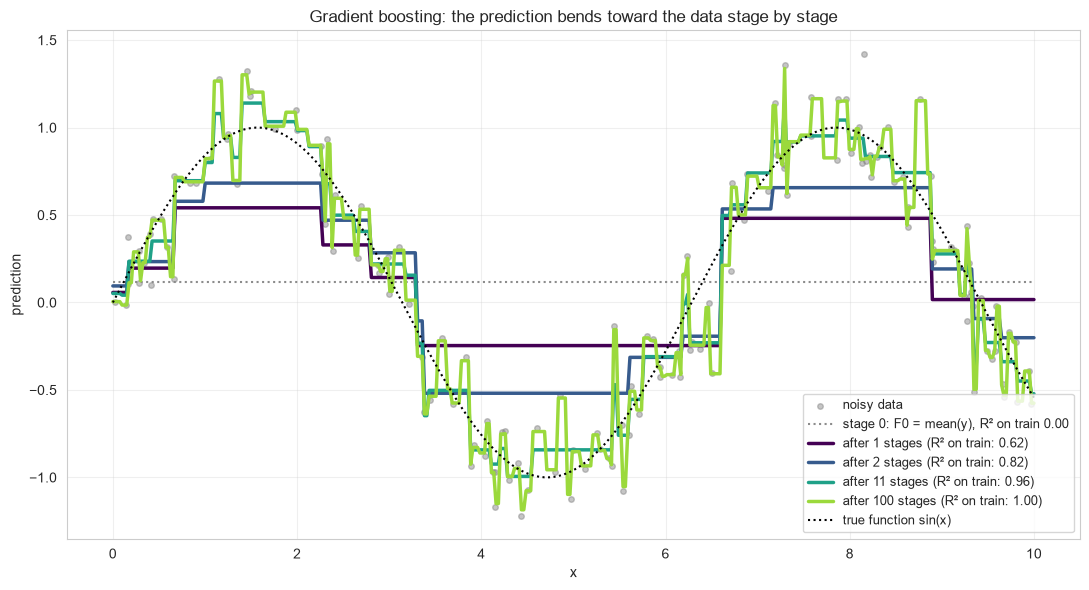


💡 Stage 0 is just the mean. Stage 1 makes the big bends where the mean is most wrong.
   Later stages only refine small local details, because the residuals they fit
   have already shrunk. That is bias reduction, one small step at a time.


In [2]:
# One fit, whole history: staged_predict yields the ensemble's state after every stage
rng = np.random.default_rng(0)
x_gb = np.sort(rng.uniform(0.0, 10.0, 150))
y_gb = np.sin(x_gb) + rng.normal(0.0, 0.20, 150)
X_gb = x_gb.reshape(-1, 1)

gbr_intro = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.5, max_depth=3, random_state=0
).fit(X_gb, y_gb)

grid_x = np.linspace(0.0, 10.0, 400).reshape(-1, 1)
# staged_predict yields exactly n_estimators entries: entry i = the model AFTER i+1 stages.
# The initial guess F0 (mean of y for squared error) is not a staged entry - draw it as
# the flat line, then show the fit after 1, 2, 11, and 100 stages.
staged_grid = list(gbr_intro.staged_predict(grid_x))
staged_train = list(gbr_intro.staged_predict(X_gb))
n_stages = len(staged_grid)
print(f"staged_predict yields {n_stages} entries: the model after stages 1..{n_stages}")

stage_views = [(0, 1), (1, 2), (10, 11), (n_stages - 1, n_stages)]

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(x_gb, y_gb, s=16, alpha=0.45, color="gray", label="noisy data")
f0_line = np.full(len(grid_x), y_gb.mean())
ax.plot(grid_x, f0_line, color="#8c8c8c", lw=1.5, ls=":",
        label=f"stage 0: F0 = mean(y), R² on train {r2_score(y_gb, np.full(len(y_gb), y_gb.mean())):.2f}")
colors = plt.cm.viridis(np.linspace(0.0, 0.85, len(stage_views)))
for color, (idx, n) in zip(colors, stage_views):
    r2 = r2_score(y_gb, staged_train[idx])
    ax.plot(grid_x, staged_grid[idx], color=color, lw=2.5,
            label=f"after {n} stages (R² on train: {r2:.2f})")
ax.plot(grid_x, np.sin(grid_x), "k:", lw=1.5, label="true function sin(x)")
ax.set_xlabel("x")
ax.set_ylabel("prediction")
ax.set_title("Gradient boosting: the prediction bends toward the data stage by stage")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Stage 0 is just the mean. Stage 1 makes the big bends where the mean is most wrong.")
print("   Later stages only refine small local details, because the residuals they fit")
print("   have already shrunk. That is bias reduction, one small step at a time.")

---

## 2. Theory & Mathematics

### Gradient Descent, but in Function Space

A supervised learner solves $\min_F \sum_i L\big(y_i, F(x_i)\big)$ for a prediction function $F$. Gradient boosting's move is to treat **the value of $F$ at each training point** as that point's coordinate, and run gradient descent on those coordinates:

$$g_i = \left[\frac{\partial L\big(y_i, F(x_i)\big)}{\partial F(x_i)}\right]_{F = F_{m-1}} \qquad \text{(per-training-point gradient)}$$

Descend by stepping $F(x_i) \leftarrow F(x_i) - \nu\, g_i$ — but that only moves the $n$ training points, and we need to score *new* points. The bridge (Friedman 2001): fit a **regression tree** $h_m$ to the pseudo-residuals $-g_i$. The tree generalizes the step direction to unseen $x$, and each stage adds it to the model:

$$F_m(x) = F_{m-1}(x) + \nu\, h_m(x)$$

So gradient boosting = **gradient descent in function space, with regression trees as the step direction**.

### The Losses and Their Pseudo-Residuals

Everything is chosen by the loss; the mechanics never change:

| Loss | Negative gradient at $F(x_i)$ | Used for |
|---|---|---|
| Squared error $\tfrac{1}{2}(y - F)^2$ | $y - F$ | regression — the *literal* residual |
| Log-loss $-\big[y\log p + (1-y)\log(1-p)\big]$, $p = \sigma(F)$ | $y - p$ | binary classification |
| Softmax deviance (multiclass) | $y_k - p_k$, one tree per class $k$ | K classes → K trees per stage |

Two properties matter for practice:

- **Residuals are bounded** for log-loss: $y - p \in [-1, 1]$. Boosting's steps cannot blow up the way squared-error residuals can.
- **Residuals vanish when confidently correct**: if $p \approx y$, the stage has almost nothing to fit, so training naturally slows near the data.

Notebook 09 (XGBoost) keeps exactly this table — its contribution is a second-order (Newton) formulation of it.

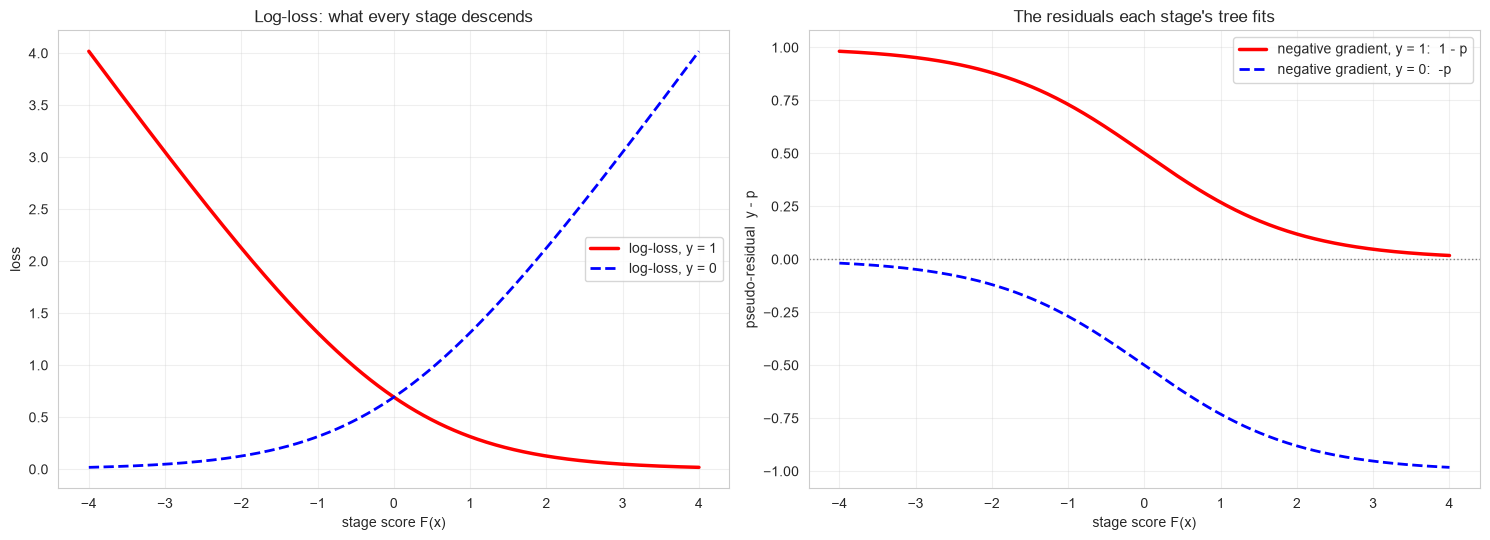

     F | p = sigmoid(F) | residual (y=1) | log-loss (y=1)
  -3.0 |          0.047 |          0.953 |          3.049
  +0.0 |          0.500 |          0.500 |          0.693
  +3.0 |          0.953 |          0.047 |          0.049

💡 Residuals are capped at 1 no matter how wrong the model is, and they vanish as
   the model becomes confident and correct — so late stages have ever less to fit.


In [3]:
F = np.linspace(-4.0, 4.0, 400)
p = 1.0 / (1.0 + np.exp(-F))                      # p = sigmoid(F)

loss_pos = -np.log(np.clip(p, 1e-12, None))       # y = 1:  L = -log(p)
loss_neg = -np.log(np.clip(1 - p, 1e-12, None))   # y = 0:  L = -log(1 - p)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(F, loss_pos, "r-", lw=2.5, label="log-loss, y = 1")
axes[0].plot(F, loss_neg, "b--", lw=2, label="log-loss, y = 0")
axes[0].set_xlabel("stage score F(x)")
axes[0].set_ylabel("loss")
axes[0].set_title("Log-loss: what every stage descends")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(F, 1.0 - p, "r-", lw=2.5, label="negative gradient, y = 1:  1 - p")
axes[1].plot(F, -p, "b--", lw=2, label="negative gradient, y = 0:  -p")
axes[1].axhline(0.0, color="gray", ls=":", lw=1)
axes[1].set_xlabel("stage score F(x)")
axes[1].set_ylabel("pseudo-residual  y - p")
axes[1].set_title("The residuals each stage's tree fits")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'F':>6s} | {'p = sigmoid(F)':>14s} | {'residual (y=1)':>14s} | {'log-loss (y=1)':>14s}")
for f in [-3.0, 0.0, 3.0]:
    pv = 1.0 / (1.0 + np.exp(-f))
    print(f"{f:+6.1f} | {pv:14.3f} | {1 - pv:14.3f} | {-np.log(pv):14.3f}")
print("\n💡 Residuals are capped at 1 no matter how wrong the model is, and they vanish as")
print("   the model becomes confident and correct — so late stages have ever less to fit.")

### Why Leaf Values Are Not Averages: the Newton Step

A least-squares regression tree stores each leaf's value as the **mean of the residuals** that land in it. That is optimal for squared error — but for log-loss the leaf's true minimizer accounts for each sample's *curvature*:

$$\gamma_{\text{leaf}} = \frac{\sum_{i \in \text{leaf}} g_i}{\sum_{i \in \text{leaf}} h_i}, \qquad g_i = y_i - p_i \;(\text{gradient}), \quad h_i = p_i\,(1 - p_i)\;(\text{curvature})$$

This **Newton step** re-weights the residuals: samples near $p = 0.5$ (maximally uncertain, maximal curvature) drive the leaf; near-certain samples (tiny $h$) barely move it. Scikit-learn and the scratch twin both apply this step to every leaf after the tree is fitted — it replaces Friedman's original one-dimensional line search. Notebook 09 (XGBoost) generalizes the same formula with an explicit $\lambda$-smoothing term.

In [4]:
# A single leaf's five training samples after stage 0 (pure NumPy, no model involved)
p_leaf = np.array([0.90, 0.20, 0.40, 0.70, 0.60])   # current probabilities
y_leaf = np.array([1.0, 1.0, 0.0, 1.0, 0.0])        # true labels

grad = y_leaf - p_leaf               # negative gradient: the residuals the tree saw
hess = p_leaf * (1.0 - p_leaf)       # log-loss curvature per sample

ls_value = float(grad.mean())                    # least-squares leaf value (the tree default)
newton_value = float(grad.sum() / hess.sum())    # the Newton step the twin applies

print(f"true labels:        {y_leaf.astype(int)}")
print(f"probabilities:      {p_leaf}")
print(f"residuals y - p:    {np.round(grad, 3)}")
print(f"curvatures p(1-p):  {np.round(hess, 3)}")
print()
print(f"least-squares leaf value (mean of residuals): {ls_value:.4f}")
print(f"Newton leaf value        (sum g / sum h):     {newton_value:.4f}")

print("\n💡 Both values shrink the leaf's loss, but they weight the samples differently.")
print("   The Newton step effectively trusts the samples that are most uncertain — the")
print("   near-certain ones have almost no gradient mass left to give.")

true labels:        [1 1 0 1 0]
probabilities:      [0.9 0.2 0.4 0.7 0.6]
residuals y - p:    [ 0.1  0.8 -0.4  0.3 -0.6]
curvatures p(1-p):  [0.09 0.16 0.24 0.21 0.24]

least-squares leaf value (mean of residuals): 0.0400
Newton leaf value        (sum g / sum h):     0.2128

💡 Both values shrink the leaf's loss, but they weight the samples differently.
   The Newton step effectively trusts the samples that are most uncertain — the
   near-certain ones have almost no gradient mass left to give.


### Shrinkage: ν Sets the Step Size

Every stage's contribution is scaled by the learning rate $\nu$ (sklearn's `learning_rate`):

$$F_M(x) = F_0(x) + \nu \sum_{m=1}^{M} h_m(x)$$

Small $\nu$ forces the ensemble to reach the same fit through *many* small, decorrelated corrections; large $\nu$ lets few trees make big moves that can overshoot. Friedman's recommendation and a decade of practice agree: **small $\nu$ with many trees generalizes better than large $\nu$ with few trees** — at the price of slower, sequential training. The sweet spot for scikit-learn-sized problems is roughly $\nu \in [0.05, 0.3]$, with $\nu$ and `n_estimators` tuned *together* (§7).

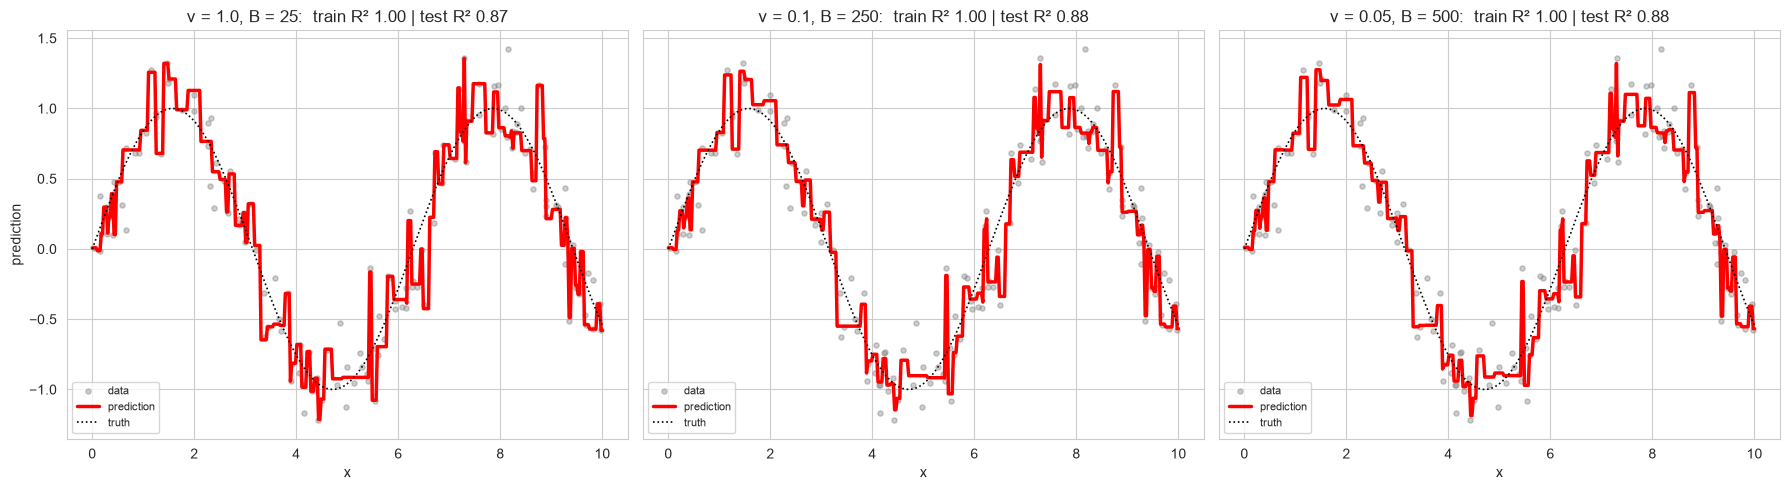

💡 All three reach a comparable fit, but by different routes: big steps overshoot and
   correct with jagged local moves, while small steps accumulate into a smoother curve.


In [5]:
# Same dataset, same algorithm, same fitted complexity class - only the step size differs
rng_sh = np.random.default_rng(0)
x_sh = np.sort(rng_sh.uniform(0.0, 10.0, 150))
y_sh = np.sin(x_sh) + rng_sh.normal(0.0, 0.2, 150)
Xs_sh = x_sh.reshape(-1, 1)
Xsh_tr, Xsh_te, ysh_tr, ysh_te = train_test_split(Xs_sh, y_sh, test_size=0.25, random_state=42)

configs = [(1.0, 25), (0.1, 250), (0.05, 500)]   # (learning_rate, n_estimators)
grid_sh = np.linspace(0.0, 10.0, 400).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (nu, B) in zip(axes, configs):
    gbr_sh = GradientBoostingRegressor(n_estimators=B, learning_rate=nu, max_depth=3,
                                       random_state=0).fit(Xsh_tr, ysh_tr)
    test_r2 = r2_score(ysh_te, gbr_sh.predict(Xsh_te))
    train_r2 = gbr_sh.score(Xsh_tr, ysh_tr)
    ax.scatter(x_sh, y_sh, s=14, alpha=0.4, color="gray", label="data")
    ax.plot(grid_sh, gbr_sh.predict(grid_sh), "r-", lw=2.5, label="prediction")
    ax.plot(grid_sh, np.sin(grid_sh), "k:", lw=1.2, label="truth")
    ax.set_xlabel("x")
    ax.set_title(f"ν = {nu}, B = {B}:  train R² {train_r2:.2f} | test R² {test_r2:.2f}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("prediction")
plt.tight_layout()
plt.show()

print("💡 All three reach a comparable fit, but by different routes: big steps overshoot and")
print("   correct with jagged local moves, while small steps accumulate into a smoother curve.")

---

## 3. Assumptions & Requirements

Gradient boosting inherits the tree base learner's distributional freedom and adds a few of its own — the most consequential one is that it will *chase noise if you let it*.

### Critical Assumptions

#### ✅ 1. **No Feature Scaling Needed**
- Trees split one feature against a threshold at a time. A monotone rescaling of a feature never changes its value ordering, so it cannot change any split
- **Contrast**: SVMs, KNN, and logistic regression all need scaling (notebooks 05–07); tree families do not
- **Demo below**: identical boosting accuracy with and without a `StandardScaler`

#### ✅ 2. **The Loss Must Match the Task**
- The negative gradient is derived *from* the loss; a wrong loss (e.g. squared error on rare events) quietly optimizes the wrong objective
- **Fix**: pick the loss deliberately — `log_loss` for classification; squared error, absolute error, Huber, or quantile for regression

#### ✅ 3. **No Missing Values in the Plain Implementations**
- `GradientBoostingClassifier/Regressor` raise on NaN. The scratch twin would propagate NaN through the tree arithmetic
- **Fix**: `SimpleImputer` inside a pipeline — or use `HistGradientBoosting*`, which supports NaN natively

#### ✅ 4. **Independent, Identically Distributed Rows**
- Stagewise fitting amplifies any pattern (temporal drift, group leakage) that links train to test rows
- **Fix**: time- or group-aware splits for temporal/clustered data

#### ✅ 5. **Enough Rows for Meaningful Leaves**
- Leaf-level Newton steps need samples to average curvature over; on tiny data the steps are noise
- Rule of thumb: from a few hundred rows, boosting starts to beat a tuned single tree

### When Assumptions Are Violated

| Violation | Symptom | Fix |
|---|---|---|
| Noisy / mislabeled rows | Train accuracy → 1.0 while test accuracy decays | Early stopping; smaller ν; check labels |
| Extrapolation required | Predictions clamp to the training range | Linear or Gaussian-process models |
| High-cardinality categoricals | Splits overfit to many-category features | Ordinal/target encoding with care; CatBoost (notebook 11) |
| Heavy class imbalance | Good accuracy, bad minority recall | Threshold moves; reweighting; per-class metrics |
| NaNs in features | Fit raises (sklearn) or corrupts the fit (twin) | Impute in a pipeline; or HistGradientBoosting |

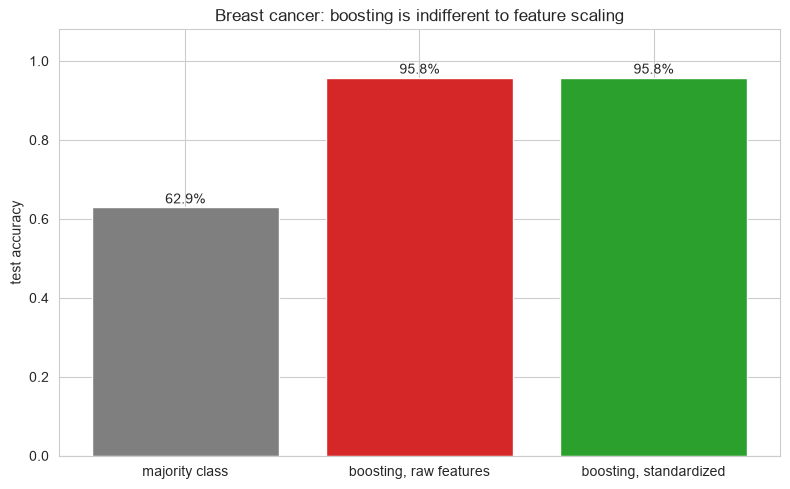

Test accuracy: majority 62.9% | raw 95.8% | standardized 95.8%

💡 Every split tests 'feature j > t'. Rescaling feature j rescales its threshold,
   never the split itself. That is why trees need no scaling - and why the SVM
   notebook's scaling demo (notebook 05) showed the opposite conclusion.


In [6]:
# The §3 demo: scaling must NOT matter for a tree ensemble (unlike SVMs/KNN/logistic)
bc_scale = load_breast_cancer()
Xsc_tr, Xsc_te, ysc_tr, ysc_te = train_test_split(
    bc_scale.data, bc_scale.target, test_size=0.25, stratify=bc_scale.target, random_state=42
)

gb_raw = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, random_state=42).fit(Xsc_tr, ysc_tr)
gb_std = Pipeline([("sc", StandardScaler()),
                   ("gb", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))])
gb_std.fit(Xsc_tr, ysc_tr)

majority_acc_sc = max(np.bincount(ysc_te)) / len(ysc_te)
acc_raw = gb_raw.score(Xsc_te, ysc_te)
acc_std = gb_std.score(Xsc_te, ysc_te)

fig, ax = plt.subplots(figsize=(8, 5))
labels_sc = ["majority class", "boosting, raw features", "boosting, standardized"]
vals_sc = [majority_acc_sc, acc_raw, acc_std]
ax.bar(labels_sc, vals_sc, color=["#7f7f7f", "#d62728", "#2ca02c"])
for i, v in enumerate(vals_sc):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_ylim(0, 1.08)
ax.set_ylabel("test accuracy")
ax.set_title("Breast cancer: boosting is indifferent to feature scaling")
plt.tight_layout()
plt.show()

print(f"Test accuracy: majority {majority_acc_sc:.1%} | raw {acc_raw:.1%} | standardized {acc_std:.1%}")
print("\n💡 Every split tests 'feature j > t'. Rescaling feature j rescales its threshold,")
print("   never the split itself. That is why trees need no scaling - and why the SVM")
print("   notebook's scaling demo (notebook 05) showed the opposite conclusion.")

---

## 4. When to Use This Algorithm

### ✅ Use Gradient Boosting When:

1. **Tabular accuracy is the priority**
   - The classical accuracy leader on structured data; the template XGBoost/LightGBM/CatBoost refine

2. **Non-linear structure with interactions exists**
   - Shallow trees capture interactions automatically; stages refine where the ensemble is still wrong

3. **Small-to-medium datasets**
   - Hundreds to tens of thousands of rows: plain sklearn is fast enough and boosting shines where a single tree would underfit or overfit

4. **You can spend time on tuning and early stopping**
   - The most hyperparameter-sensitive tree family — but the knobs (ν, B, depth) have clear, monotone stories (§7)

5. **Mixed feature types, after encoding**
   - Splits are thresholds; no scaling, no distributional assumptions. Categoricals need encoding (CatBoost handles them natively)

6. **You want probability-like outputs**
   - Log-loss boosting yields calibrated-ish probabilities out of the box — still worth checking with a reliability plot on decision-critical tasks

### ❌ Avoid Gradient Boosting When:

1. **Tiny datasets (< ~100 rows)**
   - Stagewise refinement overfits almost immediately; a linear model or a pruned single tree is steadier

2. **Extreme prediction latency**
   - Every prediction must traverse B trees, and B grows with the stages you tuned; batch predictions or distill the model when latency is tight

3. **Streaming / online learning**
   - Stages cannot be cheaply revised; `warm_start` only *appends* stages, it does not revise them

4. **Extrapolation is required**
   - Trees clamp to the training range — a non-starter for forecasting trends

5. **Very large n with plain sklearn**
   - Switch to `HistGradientBoosting*` (binned splits, native NaN support) or the libraries of notebooks 09–11

6. **Very noisy labels without early stopping**
   - Late stages fit noise-shaped residuals; without a stopping rule the test curve decays

### Classification vs Regression

| | Classification | Regression |
|---|---|---|
| Estimator | `GradientBoostingClassifier` | `GradientBoostingRegressor` |
| Loss | `log_loss` (softmax deviance for K classes; `exponential` recovers AdaBoost) | `squared_error` (also `absolute_error`, `huber`, `quantile`) |
| Initial guess F0 | log-odds of the base rate (log class priors for K classes) | the mean of $y$ |
| Trees per stage | 1 (binary), K (multiclass) | 1 |
| Scratch twin | `GradientBoostingClassifierScratch` (§5) | none — sklearn-only (§6) |

---

## 5. Implementation from Scratch (NumPy)

### Why Implement Gradient Boosting from Scratch?

- The entire algorithm is a short loop once the pieces are named — compute residuals, fit a tree, Newton-fix the leaves, add — and writing it removes the last of the magic
- The stages, their trees, and the initial guess become inspectable objects instead of internals
- It shows precisely what scikit-learn adds on top: subsampling, line search, histogram splits, per-stage deviance tracking

The twin lives in `src/models/ensemble_models.py` as **`GradientBoostingClassifierScratch`**:

- **Binary problems** stage ONE regression tree per iteration on the log-odds: $F_0$ is the log-odds of the positive base rate; each tree fits the residuals $y - p$; every leaf is replaced by the Newton step; $F \leftarrow F + \nu \cdot \text{tree.predict}$
- **Multiclass problems** stage K trees per iteration (softmax deviance): $F_0$ is the log class priors, and each of the K trees fits its class's residuals $y_k - p_k$
- It mirrors sklearn's attribute names (`classes_`, `estimators_`) and API (`fit`, `predict`, `predict_proba`, `score`); per-stage train deviance (`train_score_`) is out of scope

What is deliberately simplified (documented in the module):
- **No `subsample`** (always 1.0) and **no Friedman line search** — fitting is fully deterministic
- **No histogram trees, no parallelism** — the base learners are plain `DecisionTreeRegressorScratch` objects
- **`random_state` is accepted for API parity but unused** — nothing in the training path is random
- A single training class yields a trivial constant classifier (sklearn raises; the teaching surfaces prefer a working model)

In [7]:
# Import our from-scratch implementation
import sys
sys.path.append('../src')

from models.ensemble_models import GradientBoostingClassifierScratch
from models.tree_models import DecisionTreeRegressorScratch

print("✅ Imported custom ensemble implementations!")
print("\nAvailable class:")
print("  • GradientBoostingClassifierScratch: stagewise additive model on log-loss /")
print("    softmax deviance, with Newton leaf values")
print("\nAPI (mirrors scikit-learn's GradientBoostingClassifier names):")
print("  • .fit(X, y) runs the boosting stages")
print("  • .predict(X), .predict_proba(X), .score(X, y)")
print("  • classes_; estimators_ = list over stages, stage m holds the K regression")
print("    trees fitted at that stage (1 tree for binary, one per class otherwise)")
print("\nConstructor hyperparameters (sklearn parity):")
print("  • n_estimators=100, learning_rate=0.1, max_depth=3,")
print("    min_samples_split=2, min_samples_leaf=1, random_state (accepted, unused)")

✅ Imported custom ensemble implementations!

Available class:
  • GradientBoostingClassifierScratch: stagewise additive model on log-loss /
    softmax deviance, with Newton leaf values

API (mirrors scikit-learn's GradientBoostingClassifier names):
  • .fit(X, y) runs the boosting stages
  • .predict(X), .predict_proba(X), .score(X, y)
  • classes_; estimators_ = list over stages, stage m holds the K regression
    trees fitted at that stage (1 tree for binary, one per class otherwise)

Constructor hyperparameters (sklearn parity):
  • n_estimators=100, learning_rate=0.1, max_depth=3,
    min_samples_split=2, min_samples_leaf=1, random_state (accepted, unused)


### Classification Example (From Scratch)

Two moons — the classic interleaved geometry where a single shallow tree oscillates between under- and over-fitting — fitted by the scratch twin with 50 stages of depth-3 trees at $\nu = 0.1$ (the same setup the twin's behavioral tests use).

In [8]:
# Same moons setup as the twin's test suite (make_moons 240 / noise 0.15 / split 0.3)
Xm, ym = make_moons(n_samples=240, noise=0.15, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=42)

t0 = time.perf_counter()
gb = GradientBoostingClassifierScratch(
    n_estimators=50, learning_rate=0.1, max_depth=3
).fit(Xm_tr, ym_tr)
fit_seconds = time.perf_counter() - t0

proba_gb = gb.predict_proba(Xm_te)

print(f"fit time (50 stages, pure NumPy): {fit_seconds:.2f} s")
print(f"classes_: {gb.classes_}")
print(f"stages stored in estimators_: {len(gb.estimators_)} (trees in stage 0: {len(gb.estimators_[0])})")
print(f"F0 (log-odds of the positive base rate): {gb._f0_logit:.4f}")
print()
print(f"train accuracy: {gb.score(Xm_tr, ym_tr):.1%}")
print(f"test accuracy:  {gb.score(Xm_te, ym_te):.1%}")
print(f"probability rows sum to 1: {np.allclose(proba_gb.sum(axis=1), 1.0)}")
print(f"probabilities in [0, 1]:   {(proba_gb >= 0).all() and (proba_gb <= 1).all()}")
print("\n💡 50 small trees, added 1/10th at a time, carve out a smooth boundary on an")
print("   interleaved geometry - without any of them being individually impressive.")

fit time (50 stages, pure NumPy): 1.32 s
classes_: [0 1]
stages stored in estimators_: 50 (trees in stage 0: 1)
F0 (log-odds of the positive base rate): 0.0476

train accuracy: 100.0%
test accuracy:  95.8%
probability rows sum to 1: True
probabilities in [0, 1]:   True

💡 50 small trees, added 1/10th at a time, carve out a smooth boundary on an
   interleaved geometry - without any of them being individually impressive.


### Watching the Probability Field Sharpen

Boosting's probability field should sharpen as stages accumulate: early on it is a blurred wash around the base rate; as stages land, it develops sharp ridges along the class boundary — and, if pushed too far with a large $\nu$, islands of overconfidence around individual training points.

Four fits of the twin with increasing stage counts make this visible. Watch for the boundary between confident regions moving *and* the field's texture becoming more detailed.

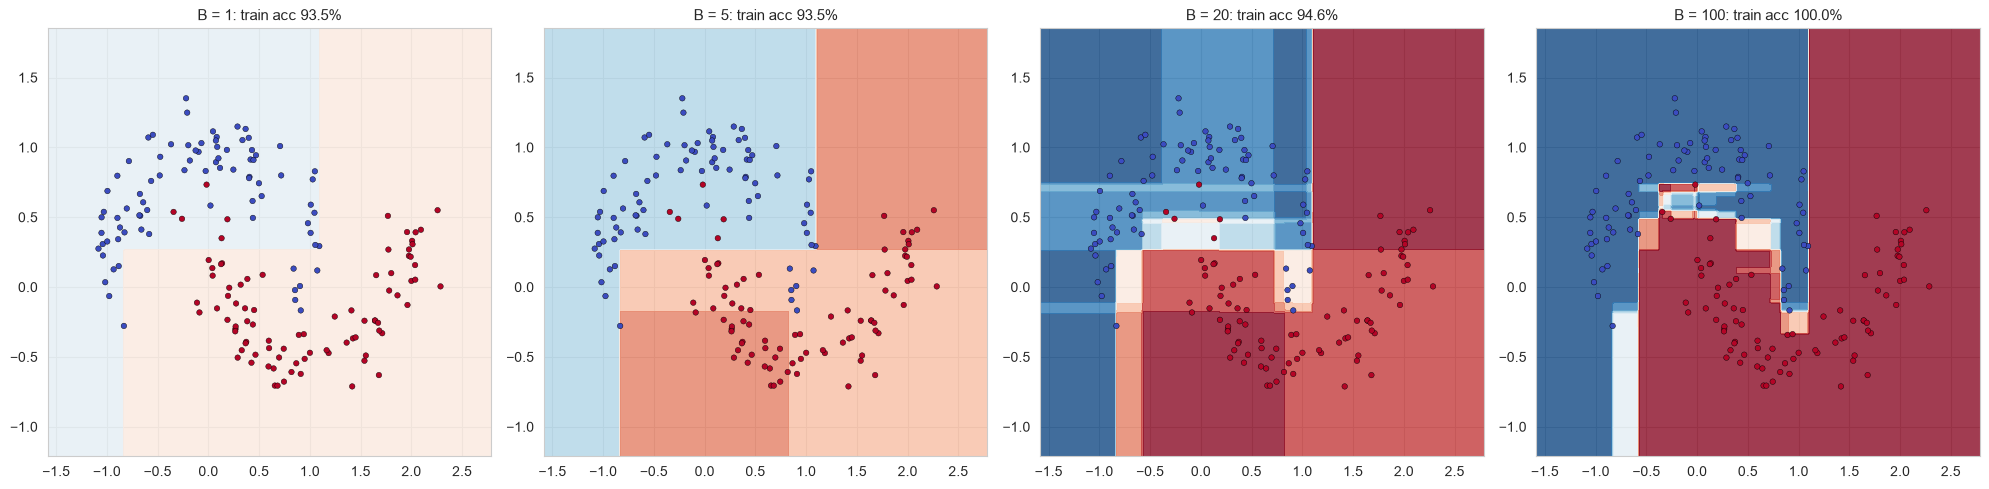


💡 B = 1 is a soft wash around the 50/50 prior. By B = 100 the ridge between the
   classes is crisp; pushing B much higher starts etching islands around outliers.


In [9]:
grid_pad = 0.5
xx_g, yy_g = np.meshgrid(
    np.linspace(Xm_tr[:, 0].min() - grid_pad, Xm_tr[:, 0].max() + grid_pad, 220),
    np.linspace(Xm_tr[:, 1].min() - grid_pad, Xm_tr[:, 1].max() + grid_pad, 220),
)
grid_pts = np.c_[xx_g.ravel(), yy_g.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, B in zip(axes, [1, 5, 20, 100]):
    gb_stage = GradientBoostingClassifierScratch(
        n_estimators=B, learning_rate=0.1, max_depth=3
    ).fit(Xm_tr, ym_tr)
    Z_field = gb_stage.predict_proba(grid_pts)[:, 1].reshape(xx_g.shape)
    ax.contourf(xx_g, yy_g, Z_field, levels=np.linspace(0.0, 1.0, 11), cmap="RdBu_r", alpha=0.8)
    ax.scatter(Xm_tr[:, 0], Xm_tr[:, 1], c=ym_tr, cmap="coolwarm", s=16,
               edgecolors="k", linewidths=0.3)
    ax.set_title(f"B = {B}: train acc {gb_stage.score(Xm_tr, ym_tr):.1%}", fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 B = 1 is a soft wash around the 50/50 prior. By B = 100 the ridge between the")
print("   classes is crisp; pushing B much higher starts etching islands around outliers.")

### Reconstructing the Stage-1 Model by Hand

The twin's whole machinery is six lines per stage. Rebuild stage 1 with plain NumPy and the twin's own leaf updater (a `classmethod`, so it works on any fitted regressor tree), then verify the result against a twin fitted with `n_estimators=1`.

The steps: initialize $F_0$, form the residuals, fit a plain regression tree to them, replace its leaf means with Newton steps, add the shrunken tree to $F$.

In [10]:
NU_HAND, DEPTH_HAND = 0.1, 3

# 1) F0: the log-odds of the positive class's base rate
pos_rate_hand = float(np.clip((ym_tr == 1).mean(), 1e-15, 1 - 1e-15))
F_hand = np.full(len(ym_tr), np.log(pos_rate_hand / (1 - pos_rate_hand)))
print(f"F0 = log-odds of base rate = {F_hand[0]:.4f}  ->  p0 = {1 / (1 + np.exp(-F_hand[0])):.3f}")

# 2) negative gradient (residuals) and curvature of log-loss
p_hand = 1.0 / (1.0 + np.exp(-F_hand))
grad_hand = ym_tr.astype(float) - p_hand
hess_hand = p_hand * (1.0 - p_hand)

# 3) a plain least-squares regression tree on the residuals...
tree_hand = DecisionTreeRegressorScratch(
    max_depth=DEPTH_HAND, min_samples_split=2, min_samples_leaf=1
).fit(Xm_tr, grad_hand)

# 4) ...whose leaf values are replaced by the Newton step (the twin's own updater)
GradientBoostingClassifierScratch._newton_leaf_values(tree_hand, Xm_tr, grad_hand, hess_hand)

# 5) the shrunken stage update
F_hand = F_hand + NU_HAND * tree_hand.predict(Xm_tr)

# verify: identical, because both paths are deterministic
twin_one = GradientBoostingClassifierScratch(
    n_estimators=1, learning_rate=NU_HAND, max_depth=DEPTH_HAND
).fit(Xm_tr, ym_tr)

p_after_hand = 1.0 / (1.0 + np.exp(-F_hand))
p_after_twin = twin_one.predict_proba(Xm_tr)[:, 1]
print(f"\nhand-rebuilt stage-1 probabilities == twin (n_estimators=1): "
      f"{np.allclose(p_after_hand, p_after_twin)}")
print("\n💡 'Gradient boosting' is not an algorithm you can't see. It is exactly these five")
print("   lines, repeated, with nothing random inside.")

F0 = log-odds of base rate = 0.0476  ->  p0 = 0.512

hand-rebuilt stage-1 probabilities == twin (n_estimators=1): True

💡 'Gradient boosting' is not an algorithm you can't see. It is exactly these five
   lines, repeated, with nothing random inside.


In [11]:
# Replay ALL stored stages by hand and check against the twin's own predict_proba
# (uses gb from the fit above; _f0_logit is the twin's stored initial score)
F_replay = np.full(len(ym_tr), gb._f0_logit)
for stage in gb.estimators_:
    for stage_tree in stage:
        F_replay += gb.learning_rate * stage_tree.predict(Xm_tr)

p_replay = 1.0 / (1.0 + np.exp(-F_replay))
p_twin_full = gb.predict_proba(Xm_tr)[:, 1]

print(f"stages replayed by hand: {len(gb.estimators_)}")
print(f"replayed probabilities == gb.predict_proba: {np.allclose(p_replay, p_twin_full)}")
print("\n💡 predict_proba is nothing more than F0 plus every stage's shrunken tree,")
print("   passed through a sigmoid. The 'model' is just the sum of its corrections.")

stages replayed by hand: 50
replayed probabilities == gb.predict_proba: True

💡 predict_proba is nothing more than F0 plus every stage's shrunken tree,
   passed through a sigmoid. The 'model' is just the sum of its corrections.


### How the Scratch Version Works (a guided tour)

Read `src/models/ensemble_models.py` alongside these facts:

**1. The initial guess F0 is a base rate, not zero (`fit`).**
Binary: $F_0 = \log\frac{r}{1-r}$ with $r$ the positive class's base rate (clipped away from 0/1), stored as `_f0_logit`. Multiclass: $F_0 = \log(\text{class priors})$, stored as `_class_prior`, floored at $10^{-15}$ for absent classes. Starting from the base rate means stage 1 fits the *deviation from the prior*, not the labels from scratch.

**2. Each stage's tree fits the negative gradient, computed fresh from the current F (`fit`).**
Binary: `grad = y - p` with curvature `p * (1 - p)`. Multiclass: for each class k, `grad_k = 1[y=k] - P_k`. Softmax inputs are clipped to ±30 (`_LOGIT_CLIP`) so `exp()` stays inside float64 range — a numerical-saturation guard, not a modeling choice.

**3. Trees are plain least-squares regressors; their leaves are then Newton-fixed (`_newton_leaf_values`).**
Each stage fits a `DecisionTreeRegressorScratch` (MSE splits, depth 3 by default) to the residuals. `_newton_leaf_values` then regroups the training samples by leaf via the tree's `apply` accessor and overwrites every leaf's `value` with $\sum g / \max(\sum h, 10^{-12})$ — the floor prevents a 0/0 on pure leaves (no gradient mass, no curvature).

**4. The stage update applies shrinkage exactly once (`fit`).**
$F \leftarrow F + \nu \cdot h_m$; the raw tree prediction is never added unscaled. `estimators_` records stage m's trees as a list: `[tree]` for binary, `[tree_0, ..., tree_{K-1}]` for multiclass — the structure the tests assert.

**5. Prediction replays the stages (`_decision` → `predict_proba`).**
$F$ is rebuilt from $F_0$ by adding $\nu \cdot h_m(x)$ over every stored stage — the same arithmetic as the replay cell above — then a sigmoid (binary) or clipped softmax (multiclass) turns scores into probabilities; `predict` takes the argmax.

**6. Edge cases are explicit.**
A single training class returns a constant classifier with `estimators_ = []` (sklearn raises here; the teaching surfaces prefer a working model). Labels need not be 0/1 — arbitrary labels are mapped through `classes_` via `searchsorted`, so `{10, 20}` works.

**7. Nothing is random (`random_state` accepted, unused).**
With `subsample` not implemented, every stage sees every row, and the base trees' split search is deterministic. Two fits on the same data give bit-identical probabilities.

**8. What scikit-learn adds beyond this skeleton.**
`subsample` row resampling with out-of-bag deviance tracking (`oob_improvement_`), Friedman's line search on top of the Newton leaves, histogram-based splitting for large data, and the per-stage train deviance curve `train_score_`. The skeletons agree; the extras differ.

---

## 6. Implementation with Scikit-learn

`GradientBoostingClassifier` runs the same stagewise skeleton with production engineering: Friedman's `friedman_mse` split criterion, terminal-region refinement on top of the Newton leaves, optional row subsampling with out-of-bag deviance, an early-stopping trio, and per-stage deviance tracking (`train_score_`).

Two subsections: the **dual-engine check** on identical data, and the **sklearn-only regressor** (the scratch twin is classifier-only).

### Dual Engine: Scratch vs Scikit-learn on the Same Data

Both engines get the same moons split, the same 100 stages, $\nu = 0.1$, depth 3. They should land close — but not bit-identical — and the reasons are worth knowing:

- **Split criterion**: sklearn's default is `friedman_mse` (a Friedman-tweaked squared-error criterion that biases the search toward split improvements that improve the fit *after* the Newton step); the twin splits on plain MSE
- **Feature order**: sklearn randomly permutes the feature order at each split (deterministic only under a fixed `random_state`); the twin always scans all features in index order
- **Shared Newton leaf updates**: for log-loss both engines size leaves by $\sum g / \sum h$, so the *shape* of the correction agrees even where split choices wobble

                                scratch    sklearn
test accuracy                     94.4%      95.8%
mean |p_scratch - p_sklearn|     0.0172           
fit time (s)                       4.29       0.06


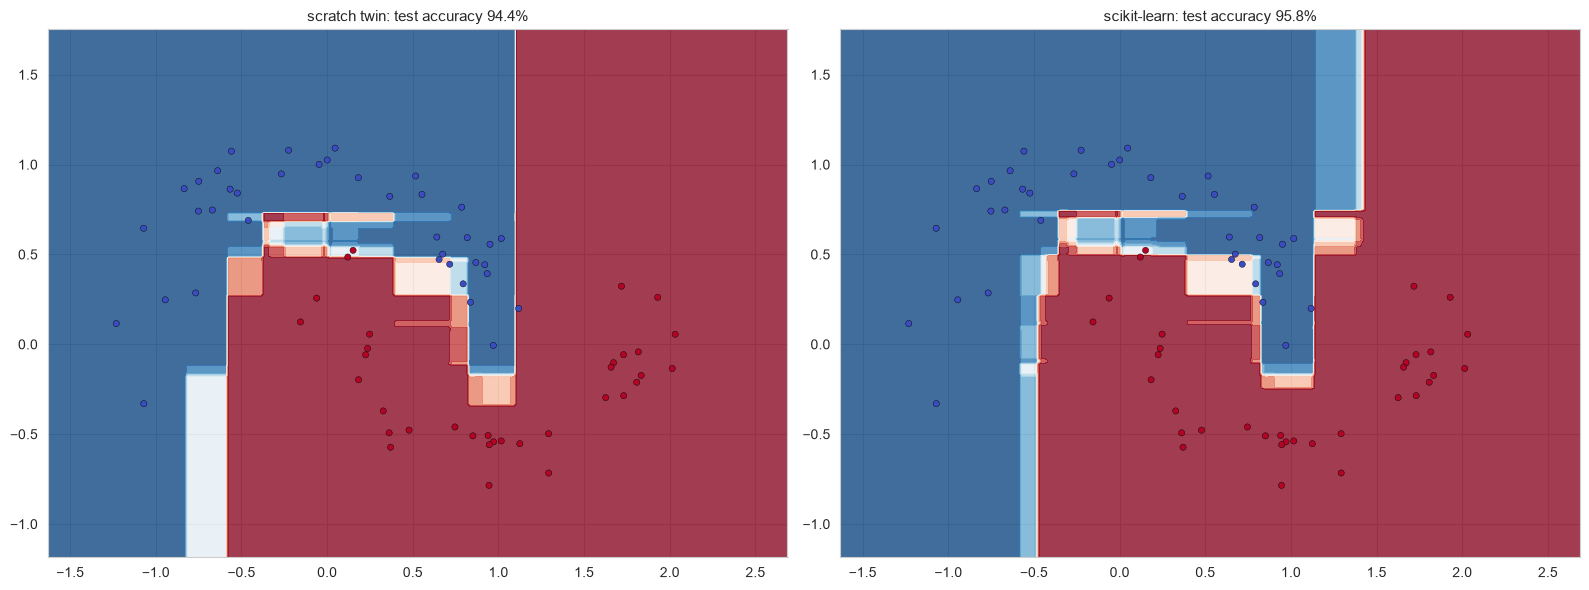


💡 Same skeleton, same leaves, slightly different split choices -> nearly the same
   boundary. The gaps shrink with more stages and smaller learning rates, because
   smaller steps average out split-level differences.


In [12]:
X_de, y_de = make_moons(n_samples=240, noise=0.15, random_state=0)
Xde_tr, Xde_te, yde_tr, yde_te = train_test_split(X_de, y_de, test_size=0.3, random_state=42)

t0 = time.perf_counter()
gb_de = GradientBoostingClassifierScratch(
    n_estimators=100, learning_rate=0.1, max_depth=3).fit(Xde_tr, yde_tr)
t_scratch = time.perf_counter() - t0

t0 = time.perf_counter()
sk_de = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0).fit(Xde_tr, yde_tr)
t_sklearn = time.perf_counter() - t0

prob_s = gb_de.predict_proba(Xde_te)[:, 1]
prob_k = sk_de.predict_proba(Xde_te)[:, 1]

print(f"{'':28s} {'scratch':>10s} {'sklearn':>10s}")
print(f"{'test accuracy':28s} {gb_de.score(Xde_te, yde_te):>10.1%} {sk_de.score(Xde_te, yde_te):>10.1%}")
print(f"{'mean |p_scratch - p_sklearn|':28s} {np.abs(prob_s - prob_k).mean():>10.4f} {'':>10s}")
print(f"{'fit time (s)':28s} {t_scratch:>10.2f} {t_sklearn:>10.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pad_de = 0.4
xx_de, yy_de = np.meshgrid(
    np.linspace(X_de[:, 0].min() - pad_de, X_de[:, 0].max() + pad_de, 250),
    np.linspace(X_de[:, 1].min() - pad_de, X_de[:, 1].max() + pad_de, 250),
)
for ax, (name, est) in zip(axes, [("scratch twin", gb_de), ("scikit-learn", sk_de)]):
    Z_de = est.predict_proba(np.c_[xx_de.ravel(), yy_de.ravel()])[:, 1].reshape(xx_de.shape)
    ax.contourf(xx_de, yy_de, Z_de, levels=np.linspace(0.0, 1.0, 11), cmap="RdBu_r", alpha=0.8)
    ax.scatter(Xde_te[:, 0], Xde_te[:, 1], c=yde_te, cmap="coolwarm", s=20,
               edgecolors="k", linewidths=0.3)
    ax.set_title(f"{name}: test accuracy {est.score(Xde_te, yde_te):.1%}", fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 Same skeleton, same leaves, slightly different split choices -> nearly the same")
print("   boundary. The gaps shrink with more stages and smaller learning rates, because")
print("   smaller steps average out split-level differences.")

### Regression with Scikit-learn: GradientBoostingRegressor

The same stagewise machinery under a different loss. For squared error the negative gradient is the *literal* residual $y - F$, and the initial guess is the mean of $y$ — so the story is even simpler than the classifier's. One nicety: with squared error the leaf mean **is** the exact minimizer, so no Newton correction is needed at all.

Two fits make the depth story visible: depth-1 stumps vs the default depth-3 trees on the same data. The regressor also accepts `absolute_error`, `huber`, and `quantile` losses — quantile boosting is a genuinely useful interval forecaster.

*(Scikit-learn only: the scratch twin covers the classifier side, where the log-loss/Newton mechanics are the interesting part.)*

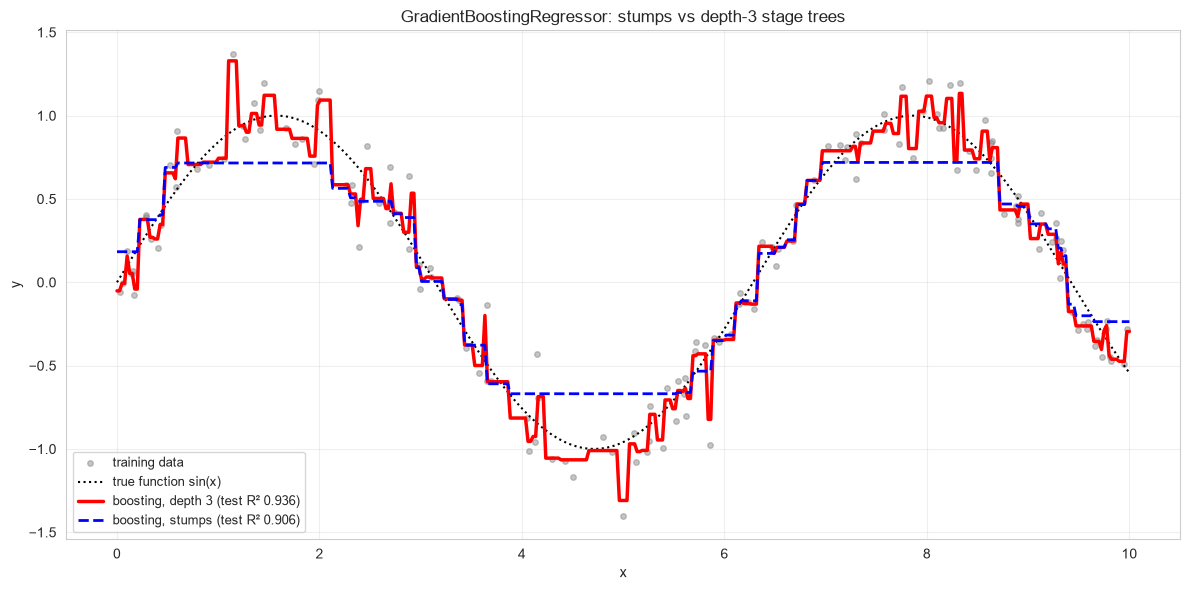

depth 3: train R² 0.9943 | test R² 0.9362
depth 1: train R² 0.9007 | test R² 0.9060

💡 Both curves track sin(x). Stumps buy smoothness at the cost of needing more
   stages for the wiggly parts - depth is the bias/variance knob *per stage*.


In [13]:
rng_r = np.random.default_rng(0)
X_r = np.sort(rng_r.uniform(0.0, 10.0, 200)).reshape(-1, 1)
y_r = np.sin(X_r).ravel() + rng_r.normal(0.0, 0.15, 200)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_r, y_r, test_size=0.25, random_state=42)

gbr_d3 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3,
                                   random_state=0).fit(Xr_tr, yr_tr)
gbr_d1 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=1,
                                   random_state=0).fit(Xr_tr, yr_tr)

grid_r = np.linspace(0.0, 10.0, 400).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(Xr_tr[:, 0], yr_tr, s=16, alpha=0.45, color="gray", label="training data")
ax.plot(grid_r, np.sin(grid_r), "k:", lw=1.5, label="true function sin(x)")
ax.plot(grid_r, gbr_d3.predict(grid_r), "r-", lw=2.5,
        label=f"boosting, depth 3 (test R² {r2_score(yr_te, gbr_d3.predict(Xr_te)):.3f})")
ax.plot(grid_r, gbr_d1.predict(grid_r), "b--", lw=2,
        label=f"boosting, stumps (test R² {r2_score(yr_te, gbr_d1.predict(Xr_te)):.3f})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("GradientBoostingRegressor: stumps vs depth-3 stage trees")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"depth 3: train R² {gbr_d3.score(Xr_tr, yr_tr):.4f} | test R² {r2_score(yr_te, gbr_d3.predict(Xr_te)):.4f}")
print(f"depth 1: train R² {gbr_d1.score(Xr_tr, yr_tr):.4f} | test R² {r2_score(yr_te, gbr_d1.predict(Xr_te)):.4f}")
print("\n💡 Both curves track sin(x). Stumps buy smoothness at the cost of needing more")
print("   stages for the wiggly parts - depth is the bias/variance knob *per stage*.")

### The Trees Behind the Ensemble

Gradient boosting is a bag of *small* regression trees with a very particular curriculum. A few structural facts worth having at your fingertips:

- **sklearn** stores its stage trees in `estimators_` as a `(B, K)` array of `DecisionTreeRegressor` objects — $K = 1$ for binary/regression, $K = n\_classes$ for multiclass. `n_trees_per_iteration_` reads the same fact directly. `apply(X)` returns each sample's leaf index per tree — the standard bridge into tree-level features.
- **the twin** stores `estimators_` as a plain list (one entry per stage, each holding that stage's trees) — same information, simpler container.
- **`feature_importances_`** follows the impurity (MDI) recipe: per-tree normalized impurity decreases, averaged over trees. Fast, but biased toward features with many split points — pair it with `permutation_importance` when a decision depends on the ranking.

sklearn estimators_ shape: (100, 1)  (B = 100 stages x K = 1 tree per stage)
apply(X) -> leaf indices of shape (143, 100, 1)


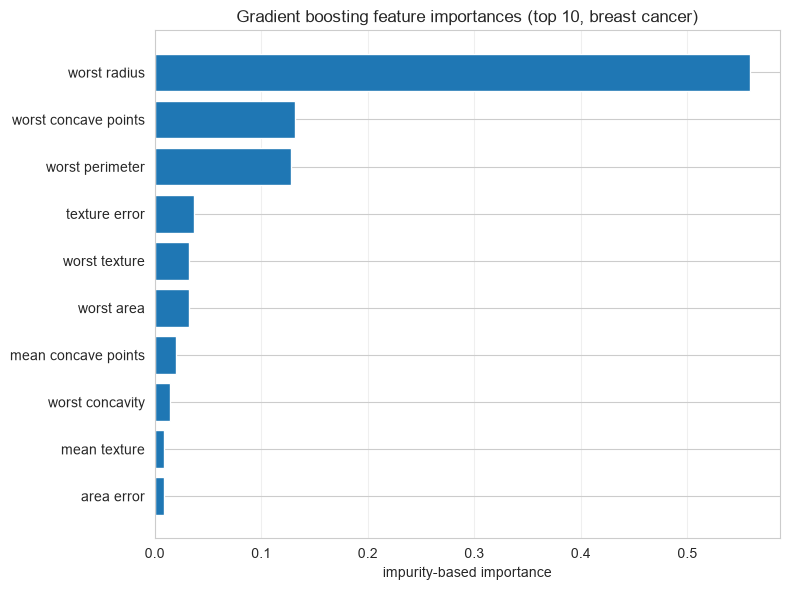

twin's container: estimators_ is a plain list - 50 stages, 1 tree per stage (binary)

💡 Importances are split-time statistics: features with more possible split
   points absorb importance even when they are not more predictive. Check any
   decision-grade ranking with permutation_importance before acting on it.


In [14]:
# Refit on the §3 breast-cancer split; inspect the stage structure and importances
clf_st = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, random_state=42).fit(Xsc_tr, ysc_tr)

print(f"sklearn estimators_ shape: {clf_st.estimators_.shape}  "
      f"(B = {clf_st.estimators_.shape[0]} stages x K = {clf_st.n_trees_per_iteration_} tree per stage)")
leaf_indices = clf_st.apply(Xsc_te)
print(f"apply(X) -> leaf indices of shape {leaf_indices.shape}")

importances = pd.Series(clf_st.feature_importances_, index=bc_scale.feature_names)
top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top10.index[::-1], top10.values[::-1], color="#1f77b4")
ax.set_xlabel("impurity-based importance")
ax.set_title("Gradient boosting feature importances (top 10, breast cancer)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"twin's container: estimators_ is a plain list - {len(gb.estimators_)} stages, "
      f"{len(gb.estimators_[0])} tree per stage (binary)")
print("\n💡 Importances are split-time statistics: features with more possible split")
print("   points absorb importance even when they are not more predictive. Check any")
print("   decision-grade ranking with permutation_importance before acting on it.")

---

## 7. Hyperparameter Tuning

For gradient boosting the levers that matter are the pair **learning_rate (ν) × n_estimators (B)** — they are one trade — plus **max_depth** (what each stage can express), and the sklearn-only extras `subsample` and the early-stopping trio. Four rules govern tuning:

1. Search **ν on a log-scale grid**, never linear — its effect is multiplicative
2. Always tune **ν and B together**; a small ν is only "slow", a large ν can be *wrong* (the overfit signature below)
3. Tune with **cross-validation on training data only**; keep the test set for the final report
4. Prefer **staged predictions** for sweeps: one fit gives the whole accuracy-vs-stage curve

The tuning data below is a noisier moons set (480 rows, noise 0.25), so the boundary has something to overfit.

In [15]:
# The tuning split used throughout §7
Xt, yt = make_moons(n_samples=480, noise=0.25, random_state=3)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.3, stratify=yt, random_state=42)
print(f"tuning data: {Xt_tr.shape[0]} train rows / {Xt_te.shape[0]} test rows, noise 0.25")

tuning data: 336 train rows / 144 test rows, noise 0.25


### The B Sweep: The Boosting Overfit Signature

Hold `max_depth = 3` fixed and sweep the stage count via `staged_predict_proba` — one fit yields the whole curve. Two learning rates make the signature visible:

- **ν = 1.0 (big steps)**: train accuracy climbs to 1.0 fast; test accuracy peaks early and then **decays** — late stages fit noise-shaped residuals
- **ν = 0.1 (small steps)**: train climbs slower, test rises and **plateaus** instead of decaying

This peak-then-decay shape is the single most recognizable plot in boosting.

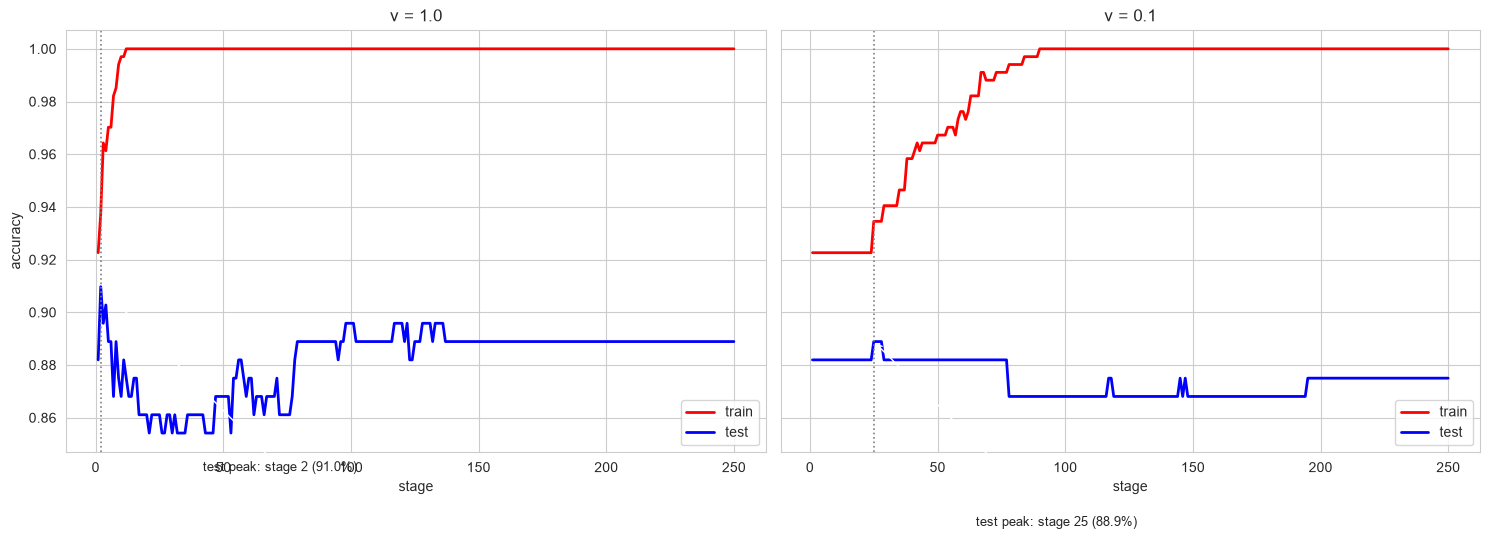

ν = 1.0: test peaks at stage 2 (91.0%), ends stage 250 at 88.9%
ν = 0.1: test peaks at stage 25 (88.9%), ends stage 250 at 87.5%

💡 Train accuracy climbs to ~1.0 in both panels - that is bias being spent. With
   ν = 1.0 the test curve decays after its peak; with ν = 0.1 it flattens instead.
   Small steps turn 'more trees = overfitting' into 'more trees = plateau'.


In [16]:
B_MAX_SWEEP = 250

def stage_curve(gb_st, X, y):
    # accuracy after every stage, from one fit's staged probabilities
    return np.array([accuracy_score(y, p.argmax(axis=1)) for p in gb_st.staged_predict_proba(X)])

gb_hi = GradientBoostingClassifier(n_estimators=B_MAX_SWEEP, learning_rate=1.0, max_depth=3,
                                   random_state=0).fit(Xt_tr, yt_tr)
gb_lo = GradientBoostingClassifier(n_estimators=B_MAX_SWEEP, learning_rate=0.1, max_depth=3,
                                   random_state=0).fit(Xt_tr, yt_tr)

curves_hi = (stage_curve(gb_hi, Xt_tr, yt_tr), stage_curve(gb_hi, Xt_te, yt_te))
curves_lo = (stage_curve(gb_lo, Xt_tr, yt_tr), stage_curve(gb_lo, Xt_te, yt_te))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, (tr_c, te_c, nu) in zip(axes, [(curves_hi[0], curves_hi[1], 1.0), (curves_lo[0], curves_lo[1], 0.1)]):
    stages_c = np.arange(1, len(tr_c) + 1)
    ax.plot(stages_c, tr_c, "r-", lw=2, label="train")
    ax.plot(stages_c, te_c, "b-", lw=2, label="test")
    best_stage = int(te_c.argmax()) + 1
    ax.axvline(best_stage, color="gray", ls=":", lw=1.2)
    ax.annotate(f"test peak: stage {best_stage} ({te_c.max():.1%})",
                xy=(best_stage, te_c.max()), xytext=(best_stage + 40, te_c.max() - 0.07),
                fontsize=9, arrowprops=dict(arrowstyle="->"))
    ax.set_xlabel("stage")
    ax.set_title(f"ν = {nu}")
    ax.legend(loc="lower right")
axes[0].set_ylabel("accuracy")
plt.tight_layout()
plt.show()

for (tr_c, te_c), nu in [(curves_hi, 1.0), (curves_lo, 0.1)]:
    print(f"ν = {nu}: test peaks at stage {int(te_c.argmax()) + 1} ({te_c.max():.1%}), "
          f"ends stage {len(te_c)} at {te_c[-1]:.1%}")
print("\n💡 Train accuracy climbs to ~1.0 in both panels - that is bias being spent. With")
print("   ν = 1.0 the test curve decays after its peak; with ν = 0.1 it flattens instead.")
print("   Small steps turn 'more trees = overfitting' into 'more trees = plateau'.")

### The ν × B Trade-off

The same total learning can be paid in different currencies: big steps few times, or small steps many times. Sweeping B for several ν values shows what each currency buys:

- **ν = 0.3**: peaks fast, then decays — the cheap-and-reckless end
- **ν = 0.1**: the practical default — rises to its plateau in ~50–150 stages
- **ν = 0.05 and 0.01**: climb slowly; eventually land as good or better, but need the larger B (or early stopping with a generous budget)

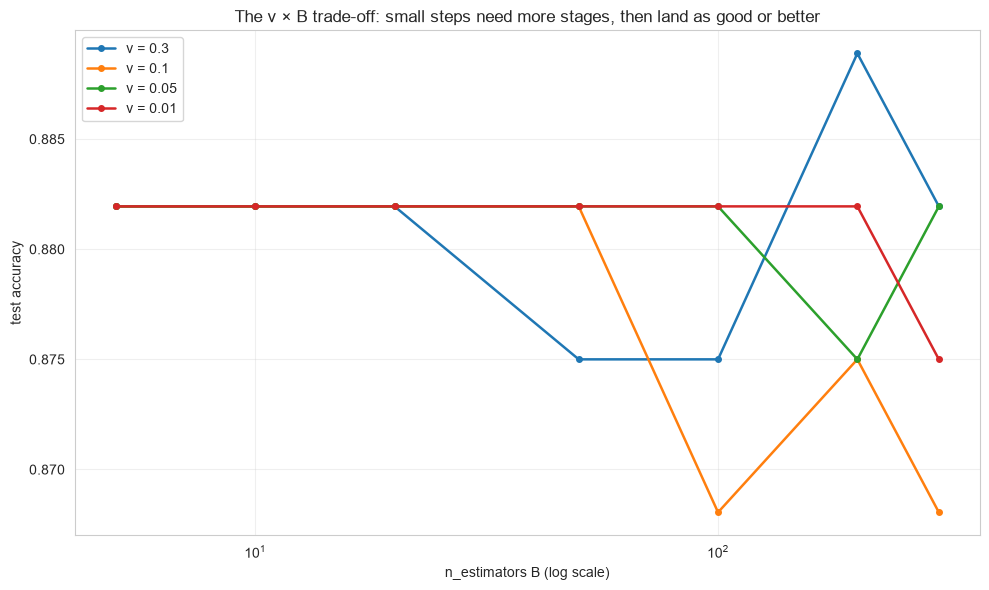

     ν |  best B | best test acc
  0.30 |     200 |         88.9%
  0.10 |       5 |         88.2%
  0.05 |       5 |         88.2%
  0.01 |       5 |         88.2%

💡 Small ν keeps improving as B grows - shrinkage trades training time for a
   steadier final fit. Pick ν by how many stages you can afford, then tune B.


In [17]:
nu_values = [0.3, 0.1, 0.05, 0.01]
B_values = [5, 10, 20, 50, 100, 200, 300]

results_by_nu = {}
for nu_v in nu_values:
    test_curve_v = []
    for B_v in B_values:
        model_v = GradientBoostingClassifier(n_estimators=B_v, learning_rate=nu_v, max_depth=3,
                                             random_state=0).fit(Xt_tr, yt_tr)
        test_curve_v.append(accuracy_score(yt_te, model_v.predict(Xt_te)))
    results_by_nu[nu_v] = np.array(test_curve_v)

fig, ax = plt.subplots(figsize=(10, 6))
for nu_v in nu_values:
    ax.plot(B_values, results_by_nu[nu_v], marker="o", ms=4, lw=1.8, label=f"ν = {nu_v}")
ax.set_xscale("log")
ax.set_xlabel("n_estimators B (log scale)")
ax.set_ylabel("test accuracy")
ax.set_title("The ν × B trade-off: small steps need more stages, then land as good or better")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'ν':>6s} | {'best B':>7s} | {'best test acc':>13s}")
for nu_v in nu_values:
    best_i = int(results_by_nu[nu_v].argmax())
    print(f"{nu_v:>6.2f} | {B_values[best_i]:>7d} | {results_by_nu[nu_v][best_i]:>13.1%}")
print("\n💡 Small ν keeps improving as B grows - shrinkage trades training time for a")
print("   steadier final fit. Pick ν by how many stages you can afford, then tune B.")

### max_depth: Stumps vs Deeper Trees

Depth is the complexity knob *per stage*: stumps (depth 1) can only correct one feature interaction at a time and need many stages; deeper trees express more per stage and overfit sooner. At ν = 0.1, four depths make the pattern concrete.

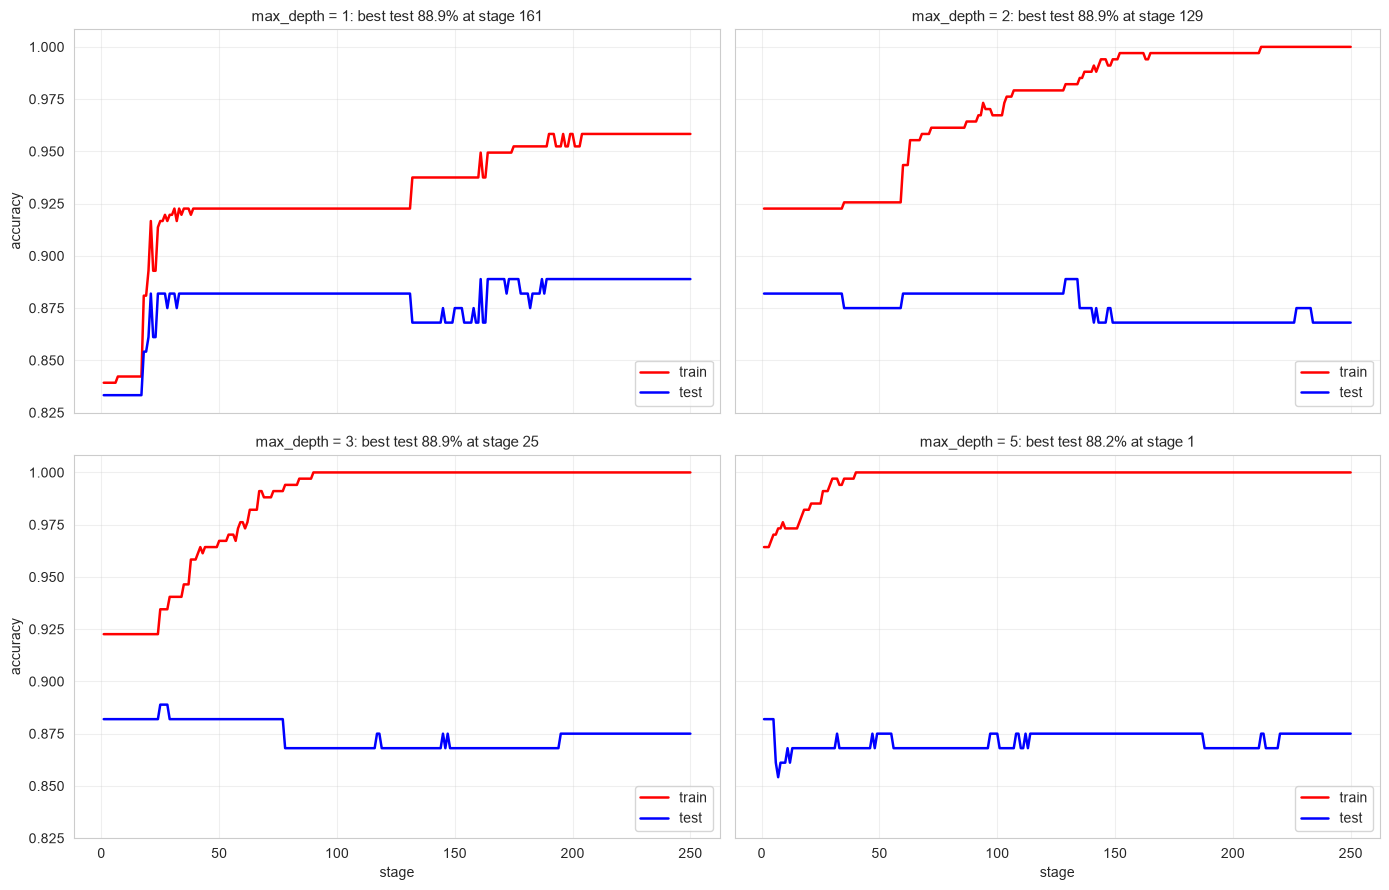

max_depth | best test acc | best stage
        1 |         88.9% |        161
        2 |         88.9% |        129
        3 |         88.9% |         25
        5 |         88.2% |          1

💡 Depths 1-3 land close to each other and stay stable for hundreds of stages.
   Depth 5 reaches train 1.0 quickly and its test curve typically peaks earlier:
   each stage is strong enough to overfit on its own. Start tuning depth at {2, 3}.


In [18]:
depth_values = [1, 2, 3, 5]
curves_by_depth = {}
for depth_v in depth_values:
    model_d = GradientBoostingClassifier(n_estimators=B_MAX_SWEEP, learning_rate=0.1,
                                         max_depth=depth_v, random_state=0).fit(Xt_tr, yt_tr)
    curves_by_depth[depth_v] = (stage_curve(model_d, Xt_tr, yt_tr),
                                stage_curve(model_d, Xt_te, yt_te))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for ax, depth_v in zip(axes.ravel(), depth_values):
    tr_d, te_d = curves_by_depth[depth_v]
    stages_d = np.arange(1, len(tr_d) + 1)
    ax.plot(stages_d, tr_d, "r-", lw=1.8, label="train")
    ax.plot(stages_d, te_d, "b-", lw=1.8, label="test")
    ax.set_title(f"max_depth = {depth_v}: best test {te_d.max():.1%} at stage {int(te_d.argmax()) + 1}",
                 fontsize=11)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy")
for ax in axes[1, :]:
    ax.set_xlabel("stage")
plt.tight_layout()
plt.show()

print(f"{'max_depth':>9s} | {'best test acc':>13s} | {'best stage':>10s}")
for depth_v in depth_values:
    te_d = curves_by_depth[depth_v][1]
    print(f"{depth_v:>9d} | {te_d.max():>13.1%} | {int(te_d.argmax()) + 1:>10d}")
print("\n💡 Depths 1-3 land close to each other and stay stable for hundreds of stages.")
print("   Depth 5 reaches train 1.0 quickly and its test curve typically peaks earlier:")
print("   each stage is strong enough to overfit on its own. Start tuning depth at {2, 3}.")

### Early Stopping and Grid Search

The early-stopping trio (`n_iter_no_change`, `validation_fraction`, `tol`) turns `n_estimators` from a target into a *budget*: training halts when a held-out validation slice stops improving. Combining that with `GridSearchCV` gives the compact tuning recipe for medium-sized problems.

In [19]:
param_grid_gs = {
    "learning_rate": [0.03, 0.1, 0.3],
    "max_depth": [2, 3],
    "subsample": [1.0, 0.8],
}
base_gs = GradientBoostingClassifier(n_estimators=200, n_iter_no_change=8,
                                     validation_fraction=0.15, random_state=0)
gs_gs = GridSearchCV(base_gs, param_grid_gs, cv=5, n_jobs=-1)
gs_gs.fit(Xt_tr, yt_tr)

print(f"best CV accuracy: {gs_gs.best_score_:.1%} with {gs_gs.best_params_}")

# a generous stage budget, held back by early stopping on the best combo
best_es = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=gs_gs.best_params_["learning_rate"],
    max_depth=gs_gs.best_params_["max_depth"],
    subsample=gs_gs.best_params_["subsample"],
    n_iter_no_change=8, validation_fraction=0.15, random_state=0,
).fit(Xt_tr, yt_tr)

print(f"requested 500 stages; early stopping used {best_es.n_estimators_}")
print(f"test accuracy of the stopped model: {best_es.score(Xt_te, yt_te):.1%}")
print("\n💡 Early stopping watches a held-out 15% slice and halts when it stops improving")
print("   for 8 consecutive stages. n_estimators becomes a budget, not a target - and")
print("   subsample < 1.0 adds row-level randomness that further steadies the test curve.")

best CV accuracy: 93.2% with {'learning_rate': 0.3, 'max_depth': 2, 'subsample': 0.8}
requested 500 stages; early stopping used 31
test accuracy of the stopped model: 89.6%

💡 Early stopping watches a held-out 15% slice and halts when it stops improving
   for 8 consecutive stages. n_estimators becomes a budget, not a target - and
   subsample < 1.0 adds row-level randomness that further steadies the test curve.


---

## 8. Complete Hyperparameter Reference

### GradientBoostingClassifier Parameters (scikit-learn 1.9)

#### `learning_rate` (float, default=0.1) **[THE HYPERPARAMETER]**
- **Description**: shrinkage ν applied to every stage's tree
- **Effect**: small ν → small, decorrelated corrections that accumulate smoothly; large ν → big steps that can overshoot and decay. Think "total learning ≈ ν × B"
- **Tuning strategy**: fix at 0.05–0.1 first, tune B to the plateau (§7); revisit ν only after depth
- **Example**: `GradientBoostingClassifier(learning_rate=0.05, n_estimators=300)`

#### `n_estimators` (int, default=100) **[THE OTHER HALF]**
- **Description**: number of boosting stages B
- **Effect**: unlike bagging, more stages **can** hurt — past the test peak, stages fit noise. With small ν and/or early stopping, more stages are safe
- **Tuning strategy**: sweep B with staged predictions (§7), or set high and let `n_iter_no_change` stop it
- **Example**: `GradientBoostingClassifier(n_estimators=500, n_iter_no_change=10)`

#### `max_depth` (int or None, default=3) **[COMPLEXITY PER STAGE]**
- **Description**: depth of each stage's regression tree
- **Effect**: 1–2 → smooth, needs more stages; 3+ → captures interactions, overfits earlier; None grows trees to purity (rarely what boosting wants)
- **Tuning strategy**: start at the default 3; try 2 for small/noisy data; >4 usually hurts
- **Example**: `GradientBoostingClassifier(max_depth=2)`

#### `loss` (str, default='log_loss')
- **Options**: `'log_loss'` (binomial/multinomial deviance — the standard) or `'exponential'` (recovers AdaBoost)
- **Effect**: defines the pseudo-residual each stage fits
- **Note**: `'exponential'` is more outlier-sensitive and yields weaker probabilities
- **Example**: `GradientBoostingClassifier(loss='exponential')`

#### `subsample` (float, default=1.0)
- **Description**: fraction of rows used to fit each stage's tree — "stochastic gradient boosting" (Friedman, 2002)
- **Effect**: values below 1.0 reduce variance and enable out-of-bag tracking (`oob_improvement_`, `oob_scores_`, `oob_score_`)
- **Tuning strategy**: try 0.7–0.9 when overfitting persists after ν/depth tuning; interacts with B
- **Example**: `GradientBoostingClassifier(subsample=0.8)`

#### `max_features` ({'sqrt','log2'}, int, float, or None, default=None)
- **Description**: features considered per split. The default None (all features) keeps each stage tree as good as possible — the opposite trade-off from random forests, where small subsets *help*
- **Example**: `GradientBoostingClassifier(max_features='sqrt')` for very high-dimensional data

#### `min_samples_split` / `min_samples_leaf` (int or float, default 2 / 1)
- **Description**: per-tree regularization, exactly as for plain trees (notebook 03); floats are fractions of n
- **Effect**: larger values → smoother leaves → weaker but steadier stages
- **Example**: `min_samples_leaf=5` on small or noisy data

#### `min_weight_fraction_leaf` (float, default=0.0)
- **Description**: minimum weighted fraction of samples per leaf
- **Note**: `min_samples_leaf` covers most needs; rarely tuned separately

#### `max_leaf_nodes` (int, default=None)
- **Description**: grow each stage's tree best-first, capped at K leaves — an alternative to `max_depth`
- **Example**: `max_leaf_nodes=8` ≈ a wider, shallower depth-3 tree

#### `min_impurity_decrease` (float, default=0.0)
- **Description**: split only if impurity drops by at least this (weighted by node share)
- **Example**: `min_impurity_decrease=0.01` for conservative stage trees

#### `init` (estimator or 'zero', default=None)
- **Description**: a custom initial guess F0; by default a `DummyEstimator` predicting the class priors (log class priors in log-odds space)
- **Example**: pass a fitted model whose predictions are a better starting point than the base rate

#### `n_iter_no_change` / `validation_fraction` / `tol` (None / 0.1 / 1e-4) **[EARLY STOPPING TRIO]**
- **Description**: setting `n_iter_no_change` to an int holds out `validation_fraction` of the training rows (stratified) and stops when validation loss fails to improve by `tol` for that many consecutive stages
- **Effect**: the single most valuable extra on plain GBC; `n_estimators_` reports how many stages actually ran
- **Example**: `GradientBoostingClassifier(n_estimators=500, n_iter_no_change=8)`

#### `ccp_alpha` (float, default=0.0)
- **Description**: minimal cost-complexity pruning of each stage tree (same mechanic as notebook 03's post-pruning)
- **Example**: `ccp_alpha=0.01` to shrink each stage's tree

#### `warm_start` (bool, default=False)
- **Description**: refit with a larger `n_estimators` appends stages instead of restarting
- **Example**: `warm_start=True` to extend an ensemble interactively without paying for old stages again

#### `random_state` (int, default=None)
- **Description**: seeds the per-stage tree randomness and the split-time feature permutation (deterministic output when fixed); also seeds the validation split for early stopping

#### `verbose` (int, default=0)
- **Description**: training progress printing (1 = occasional, >1 = every stage)

#### `criterion` (deprecated in 1.9, removal in 1.11)
- **Description**: historically chose the split criterion; has had no effect for years. Do not pass it in new code

### Fitted Attributes Worth Knowing

- `train_score_` (B,) — per-stage training deviance; plot against stage number to watch fitting progress
- `n_trees_per_iteration_` — 1 for binary, K for multiclass; `estimators_` has shape (B, K)
- `feature_importances_` — impurity-based MDI importances (see §6's caveats)
- `apply(X)` — per-sample leaf indices of shape (n, B, K); the standard bridge into tree-level features
- `oob_improvement_` / `oob_scores_` / `oob_score_` — out-of-bag deviance history, only when `subsample < 1.0`
- `staged_predict` / `staged_predict_proba` / `staged_decision_function` — generators over stage-by-stage predictions (used throughout §7)

### What the Scratch Twin Covers

| sklearn parameter | twin | Notes |
|---|---|---|
| `n_estimators`, `learning_rate` | ✅ | identical meaning; shrinkage applied once per stage |
| `max_depth`, `min_samples_split`, `min_samples_leaf` | ✅ | passed straight to the stage trees |
| `loss` | partial | log-loss (binary) and softmax deviance (multiclass) only |
| `subsample`, line search, histogram splits, `train_score_` | ❌ | documented simplifications; fits are fully deterministic |
| `n_iter_no_change` and friends | ❌ | no deviance tracking, so nothing to stop on |

---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **Tune in the Right Order: ν → B → depth → subsample**
`learning_rate` and `n_estimators` are one trade; depth changes what each stage can express. Fixing ν at 0.05–0.1, sweeping B to the plateau, then depth, then subsample keeps the search small and legible.

#### 2. **Let Early Stopping Hold the Stopwatch**
On medium data, set a generous stage budget and stop on validation loss instead of micro-managing B:
```python
from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, n_iter_no_change=10)
```

#### 3. **Diagnose with Staged Deviance, Not Just Accuracy**
Plot `train_score_` plus staged test loss: a flattening test curve is healthy; a decaying one says stop earlier (or shrink ν).

#### 4. **Impute Inside a Pipeline**
Plain GBC raises on NaN; the twin corrupts. Make imputation structural, not ad hoc:
```python
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                 ("gb", GradientBoostingClassifier())])
```

#### 5. **Prefer HistGradientBoosting for Larger Data**
`HistGradientBoostingClassifier/Regressor` bin features (fast splits), support NaN natively, and expose similar hyperparameters. Plain GBC is the teaching reference; HistGB is the workhorse.

#### 6. **Verify Importances Before Acting**
Impurity importances favor features with many split points; `permutation_importance` is the honest ranking for decisions.

#### 7. **Small ν × Many Trees Beats Big ν × Few Trees**
Friedman's rule, verified in §7: the same accuracy arrives steadier when paid in many small corrections. Budget training time accordingly.

### ❌ Common Mistakes

#### 1. **A Big Learning Rate with Many Stages and No Stopping**
```python
# BAD:  GradientBoostingClassifier(n_estimators=500, learning_rate=1.0)   # train 1.0, test decays
# GOOD: GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, n_iter_no_change=10)
```

#### 2. **Tuning Everything at Once**
```python
# BAD:  a full grid over ν, B, depth, subsample, min_samples... - hundreds of opaque fits
# GOOD: staged tuning: ν, then B, then depth, then subsample - a few dozen legible fits
```

#### 3. **Reading the Test Curve to Choose Where to Stop**
```python
# BAD:  n_estimators = stage where the TEST curve peaked          (leaked)
# GOOD: choose via CV / early stopping's validation slice; test set stays untouched
```

#### 4. **Feeding NaNs to Plain GBC**
```python
# BAD:  GradientBoostingClassifier().fit(X_with_nan, y)    # ValueError
# GOOD: impute in a pipeline, or use HistGradientBoostingClassifier (native NaN support)
```

#### 5. **Treating Probabilities as Calibrated by Default**
High B with large ν produces confident wrong predictions. On decision-critical tasks, check a reliability plot / Brier score (§10 does), and consider `CalibratedClassifierCV` as in notebook 05.

#### 6. **Hiding Imbalance Behind Accuracy**
Boosting happily boosts the majority. Report per-class recall and consider reweighting or threshold moves when one class is rare.

---

## 10. Real-world Examples

Two examples chosen as a **pair of contrasts**:

- **Example 1: Breast Cancer Diagnosis (binary, medical).** The decision is clinical and the important errors are missed malignant tumors. The workflow is a small grid search with early stopping, per-class reporting, and a probability read (histogram + Brier score) with a threshold note.
- **Example 2: Handwritten Digits (10 classes, image features).** Multiclass boosting stages **10 trees per class per stage** — the K-trees-per-stage mechanics of §5 at real scale. The workflow is a single fit, per-class f1, confusion analysis, and a gallery of misclassified digits.

Both datasets are bundled with scikit-learn, so no download is needed. Both run on scikit-learn at full size — the scratch twin is sized for few-hundred-row fits, so it is not used here.

In [20]:
# Example 1: breast cancer diagnosis - compact grid + early stopping + per-class report
bc = load_breast_cancer()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bc.data, bc.target, test_size=0.25,
                                              stratify=bc.target, random_state=42)

param_grid_bc = {"learning_rate": [0.03, 0.1, 0.2], "max_depth": [2, 3]}
gs_bc = GridSearchCV(
    GradientBoostingClassifier(n_estimators=300, n_iter_no_change=8,
                               validation_fraction=0.15, random_state=42),
    param_grid_bc, cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1,
)
gs_bc.fit(Xb_tr, yb_tr)
best_bc = gs_bc.best_estimator_
pred_bc = best_bc.predict(Xb_te)

print(f"best CV accuracy: {gs_bc.best_score_:.1%} with {gs_bc.best_params_}")
print(f"early stopping used {best_bc.n_estimators_} of the requested 300 stages")
print(f"test accuracy: {best_bc.score(Xb_te, yb_te):.1%}")

cm_bc = confusion_matrix(yb_te, pred_bc)
print("\nClassification report (benign = positive class, sklearn's convention):")
print(classification_report(yb_te, pred_bc, target_names=["malignant (0)", "benign (1)"]))
print(f"confusion matrix rows = true, columns = predicted: {cm_bc.tolist()}")
print(f"missed malignant tumors (predicted benign): {cm_bc[0, 1]} of {cm_bc[0].sum()}")

best CV accuracy: 96.3% with {'learning_rate': 0.1, 'max_depth': 3}
early stopping used 108 of the requested 300 stages
test accuracy: 95.1%

Classification report (benign = positive class, sklearn's convention):
               precision    recall  f1-score   support

malignant (0)       0.96      0.91      0.93        53
   benign (1)       0.95      0.98      0.96        90

     accuracy                           0.95       143
    macro avg       0.95      0.94      0.95       143
 weighted avg       0.95      0.95      0.95       143

confusion matrix rows = true, columns = predicted: [[48, 5], [2, 88]]
missed malignant tumors (predicted benign): 5 of 53


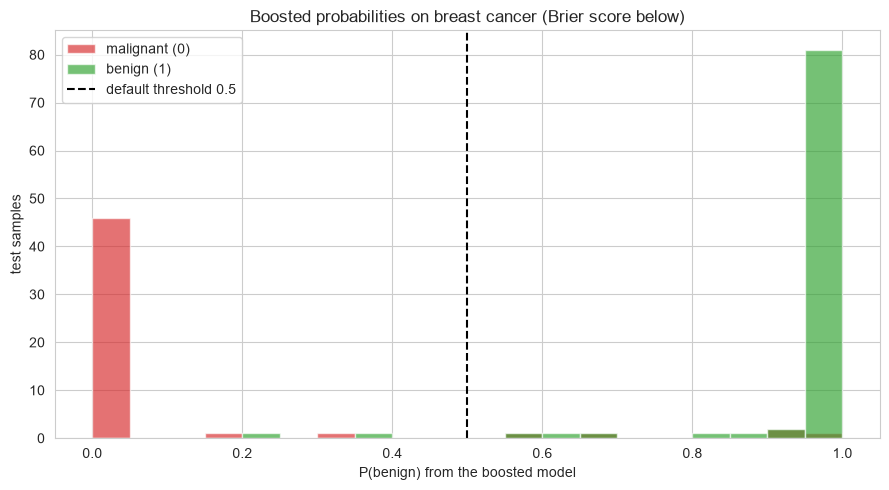

Brier score: 0.0358  (0 = perfect probabilities, 0.25 = uninformed)

💡 The p = 0.5 cut is a choice, not a law. For a screening task a clinic might
   act at P(malignant) > 0.2: lowering the threshold trades false alarms for
   fewer missed cancers - exactly the trade the confusion matrix above prices.


In [21]:
# ...and the probability read: where do the two classes' scores land?
proba_bc = best_bc.predict_proba(Xb_te)[:, 1]      # P(benign)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(proba_bc[yb_te == 0], bins=np.linspace(0, 1, 21), alpha=0.65,
        color="#d62728", label="malignant (0)")
ax.hist(proba_bc[yb_te == 1], bins=np.linspace(0, 1, 21), alpha=0.65,
        color="#2ca02c", label="benign (1)")
ax.axvline(0.5, color="k", ls="--", lw=1.5, label="default threshold 0.5")
ax.set_xlabel("P(benign) from the boosted model")
ax.set_ylabel("test samples")
ax.set_title("Boosted probabilities on breast cancer (Brier score below)")
ax.legend()
plt.tight_layout()
plt.show()

brier_bc = brier_score_loss(yb_te, proba_bc)
print(f"Brier score: {brier_bc:.4f}  (0 = perfect probabilities, 0.25 = uninformed)")
print("\n💡 The p = 0.5 cut is a choice, not a law. For a screening task a clinic might")
print("   act at P(malignant) > 0.2: lowering the threshold trades false alarms for")
print("   fewer missed cancers - exactly the trade the confusion matrix above prices.")

### Example 2: Handwritten Digits (10 Classes, One Tree per Class per Stage)

The digits dataset (1797 images, 8×8 grayscale, 10 classes) exercises the **multiclass branch**: softmax deviance stages K = 10 regression trees per iteration, so 100 stages fit 1000 small trees. Expect the fit to be the slowest cell in this notebook — multiclass boosting pays the K multiplier.

multiclass boosting: 10 trees per stage x 100 stages = 1000 trees total
fit time: 4.9 s  (the K-trees-per-stage multiplier in action)
test accuracy: 97.1%


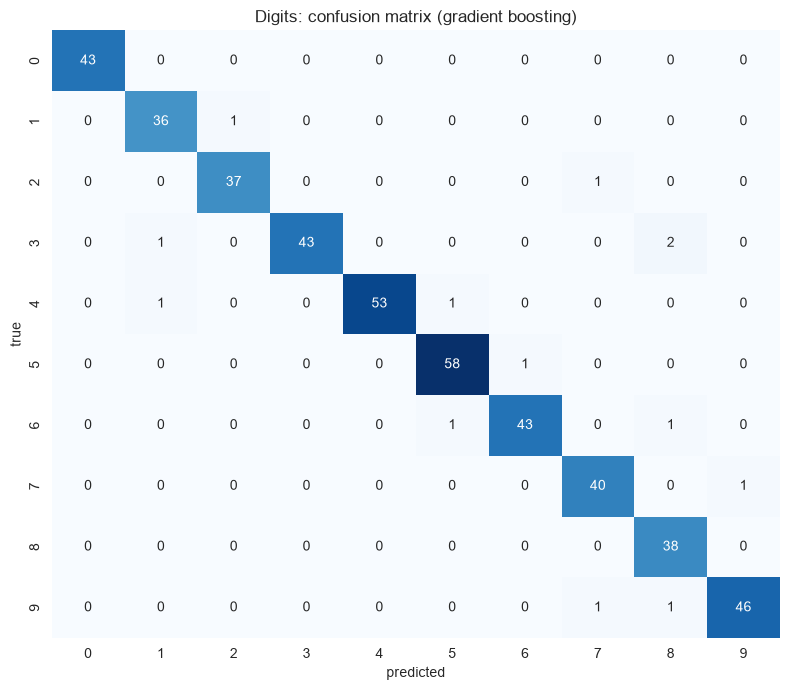

Per-class f1 - where boosting struggles most:
  class 0: f1 = 1.000
  class 1: f1 = 0.960
  class 2: f1 = 0.974
  class 3: f1 = 0.966
  class 4: f1 = 0.981
  class 5: f1 = 0.975
  class 6: f1 = 0.966
  class 7: f1 = 0.964
  class 8: f1 = 0.950
  class 9: f1 = 0.968


In [22]:
digits = load_digits()
Xd_tr, Xd_te, yd_tr, yd_te, img_tr, img_te = train_test_split(
    digits.data, digits.target, digits.images, test_size=0.25, random_state=42
)

t0 = time.perf_counter()
clf_d = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                   random_state=42).fit(Xd_tr, yd_tr)
t_digits = time.perf_counter() - t0
pred_d = clf_d.predict(Xd_te)

print(f"multiclass boosting: {clf_d.n_trees_per_iteration_} trees per stage "
      f"x {clf_d.n_estimators_} stages = {clf_d.n_estimators_ * clf_d.n_trees_per_iteration_} trees total")
print(f"fit time: {t_digits:.1f} s  (the K-trees-per-stage multiplier in action)")
print(f"test accuracy: {clf_d.score(Xd_te, yd_te):.1%}")

cm_d = confusion_matrix(yd_te, pred_d)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Digits: confusion matrix (gradient boosting)")
plt.tight_layout()
plt.show()

report_d = classification_report(yd_te, pred_d, output_dict=True)
print("Per-class f1 - where boosting struggles most:")
for digit_k in range(10):
    print(f"  class {digit_k}: f1 = {report_d[str(digit_k)]['f1-score']:.3f}")

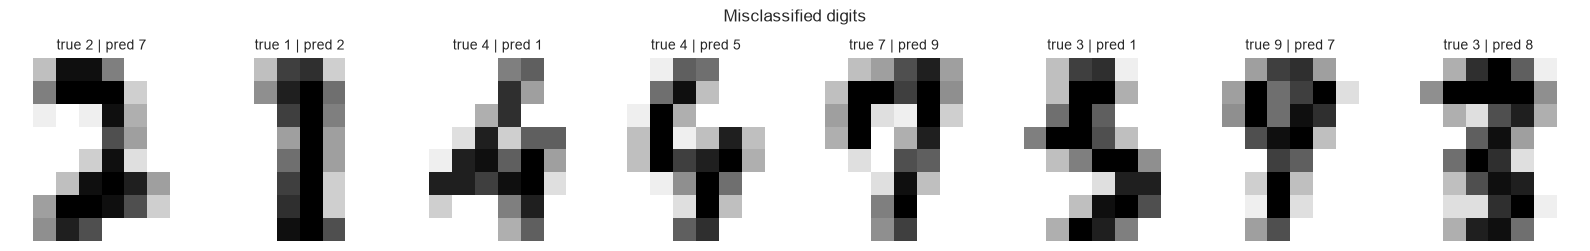

13 of 450 test digits misclassified

💡 Typical confusions (1↔8, 9↔5, 3↔8) are the genuinely ambiguous strokes - the
   model's errors are human-legible, which is one reason image tasks later moved
   to representation learning (notebook 17).


In [23]:
# ...and the misclassified digits, as images: the confusions are the ambiguous strokes
miss_idx = np.where(pred_d != yd_te)[0]
show_idx = miss_idx[:8]

fig, axes = plt.subplots(1, max(len(show_idx), 1), figsize=(16, 2.6))
if len(show_idx) == 1:
    axes = [axes]
for ax, idx in zip(axes, show_idx):
    ax.imshow(img_te[idx], cmap="gray_r")
    ax.set_title(f"true {yd_te[idx]} | pred {pred_d[idx]}", fontsize=10)
    ax.axis("off")
plt.suptitle("Misclassified digits")
plt.tight_layout()
plt.show()

print(f"{len(miss_idx)} of {len(yd_te)} test digits misclassified")
print("\n💡 Typical confusions (1↔8, 9↔5, 3↔8) are the genuinely ambiguous strokes - the")
print("   model's errors are human-legible, which is one reason image tasks later moved")
print("   to representation learning (notebook 17).")

---

## 11. Comparison with Other Algorithms

### When to Choose Gradient Boosting vs Alternatives

| Aspect | Gradient Boosting | Random Forest | AdaBoost | Single Tree | Logistic Regression |
|---|---|---|---|---|---|
| **Error it targets** | bias (stage by stage) | variance (averaging) | bias (reweighting) | — | bias (direct fit) |
| **Base learners** | shallow regression trees (depth 3) | deep trees, decorrelated | stumps (default) | one full tree | linear boundary |
| **Hyperparameter sensitivity** | ⭐⭐⭐ (ν, B, depth all matter) | ⭐ (robust at defaults) | ⭐⭐ | ⭐⭐⭐ (pruning) | ⭐ |
| **Overfit behavior** | test can peak then decay | plateaus | usually mild | immediate | smooth |
| **Probability quality** | good (verify on critical tasks) | good | weak (label-ish) | poor | good |
| **Train speed** | sequential (stages depend on predecessors) | parallelizable (`n_jobs`) | sequential | fastest | fast |
| **Noisy labels** | sensitive (chases residuals) | robust | very sensitive | sensitive | robust |
| **Feature scaling needed** | ❌ | ❌ | ❌ | ❌ | ✅ |
| **Interpretability** | ⭐⭐ (many small trees) | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |

The **error-target row** is the fork in the road: boosting buys bias reduction stepwise; bagging buys variance reduction with independent votes. When both are tuned, boosting usually edges out random forests on accuracy — for more tuning effort, higher noise sensitivity, and no parallelism.

### Practical Comparison

The same 5-fold CV protocol on three geometries: 3-class blobs (interacting cluster structure), noisy moons (curved boundary), and real breast cancer data. Every model at sensible defaults, fixed seeds.

In [24]:
def cv_accuracy(est_cv, X_c, y_c):
    # 5-fold stratified CV accuracy for one model on one dataset
    return cross_val_score(est_cv, X_c, y_c, cv=StratifiedKFold(5, shuffle=True, random_state=0),
                           scoring="accuracy")

bc_cmp = load_breast_cancer()
datasets_cmp = {
    "blobs (3-class)": make_blobs(n_samples=600, centers=3, cluster_std=2.0, random_state=0),
    "moons (noisy)": make_moons(n_samples=600, noise=0.25, random_state=0),
    "breast cancer": (bc_cmp.data, bc_cmp.target),
}
models_cmp = {
    "Single tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=0),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=0),
    "Logistic Regression": Pipeline([("sc", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000))]),
}

rows_cmp = []
for ds_name, (X_c, y_c) in datasets_cmp.items():
    for m_name, est_c in models_cmp.items():
        scores_c = cv_accuracy(est_c, X_c, y_c)
        rows_cmp.append({"model": m_name, "dataset": ds_name,
                         "mean": scores_c.mean(), "std": scores_c.std()})

df_cmp = pd.DataFrame(rows_cmp).pivot(index="model", columns="dataset", values="mean")
order_cmp = ["blobs (3-class)", "moons (noisy)", "breast cancer"]
df_cmp = df_cmp[order_cmp]
print(df_cmp.round(3).to_string())

gb_row = df_cmp.loc["Gradient Boosting"]
rf_row = df_cmp.loc["Random Forest"]
wins = int((gb_row > rf_row).sum())
print(f"\nGradient boosting beats random forest on {wins} of 3 geometries (mean CV accuracy)")
print("💡 The margins are small and geometry-dependent - which is the honest summary of")
print("   boosting vs bagging: a slightly better ceiling, for more tuning and less robustness.")

dataset                blobs (3-class)  moons (noisy)  breast cancer
model                                                               
AdaBoost                         0.672          0.930          0.972
Gradient Boosting                0.692          0.928          0.965
Logistic Regression              0.693          0.878          0.979
Random Forest                    0.632          0.920          0.965
Single tree (depth 3)            0.653          0.893          0.930

Gradient boosting beats random forest on 2 of 3 geometries (mean CV accuracy)
💡 The margins are small and geometry-dependent - which is the honest summary of
   boosting vs bagging: a slightly better ceiling, for more tuning and less robustness.


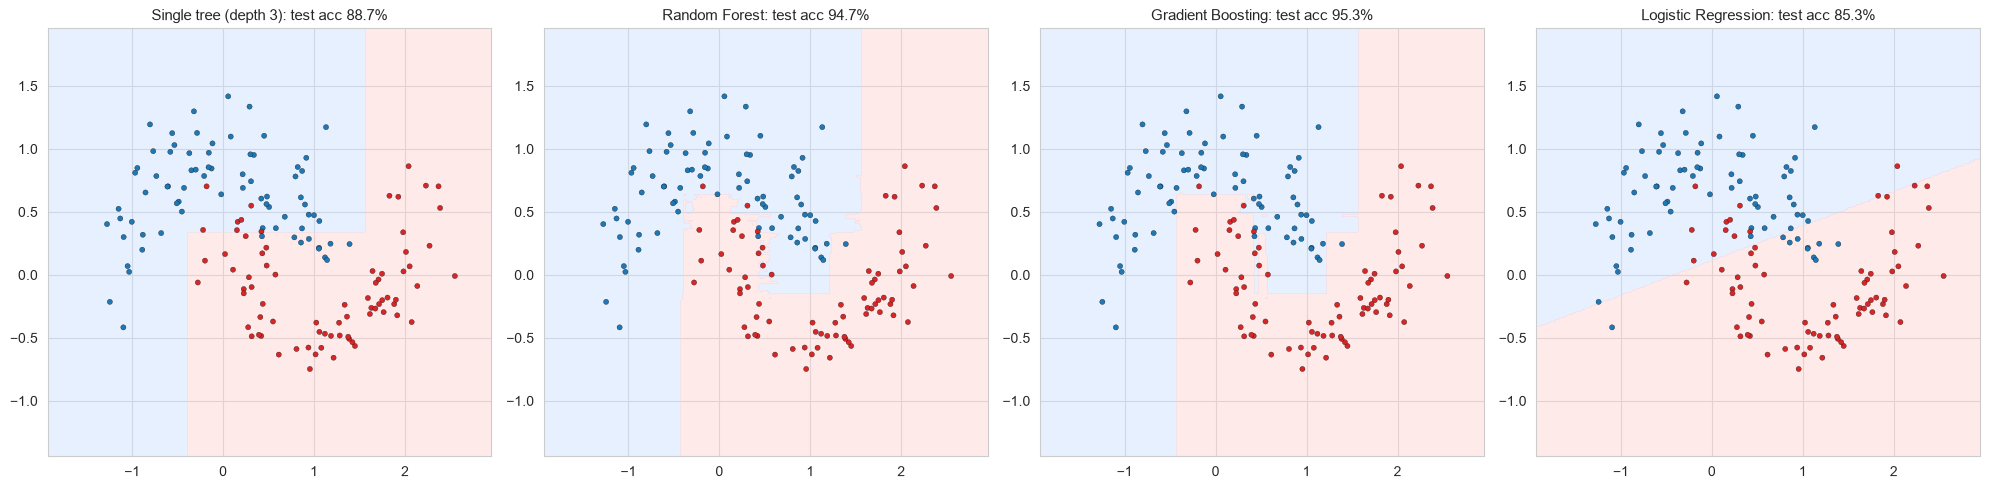


💡 The single tree's boundary is blocky; the forest's is blocky in a different way;
   boosting's is the smoothest of the tree models - many small corrections average
   out the wiggles. Logistic regression stays linear and pays for it here.


In [25]:
# The boundary shapes behind the numbers: four families on the noisy moons geometry
X_bo, y_bo = make_moons(n_samples=500, noise=0.22, random_state=42)
Xbo_tr, Xbo_te, ybo_tr, ybo_te = train_test_split(X_bo, y_bo, test_size=0.3,
                                                  stratify=y_bo, random_state=42)
families_bo = {
    "Single tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=0),
    "Logistic Regression": Pipeline([("sc", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000))]),
}
pad_bo = 0.4
xx_bo, yy_bo = np.meshgrid(
    np.linspace(X_bo[:, 0].min() - pad_bo, X_bo[:, 0].max() + pad_bo, 250),
    np.linspace(X_bo[:, 1].min() - pad_bo, X_bo[:, 1].max() + pad_bo, 250),
)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, est_bo) in zip(axes, families_bo.items()):
    est_bo.fit(Xbo_tr, ybo_tr)
    Z_bo = est_bo.predict(np.c_[xx_bo.ravel(), yy_bo.ravel()]).reshape(xx_bo.shape)
    ax.contourf(xx_bo, yy_bo, Z_bo, levels=[-0.5, 0.5, 1.5], colors=["#cfe2ff", "#ffd6d6"], alpha=0.5)
    ax.scatter(Xbo_te[:, 0], Xbo_te[:, 1], c=np.where(ybo_te == 1, "#d62728", "#1f77b4"),
               s=14, edgecolors="k", linewidths=0.2)
    ax.set_title(f"{name}: test acc {est_bo.score(Xbo_te, ybo_te):.1%}", fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 The single tree's boundary is blocky; the forest's is blocky in a different way;")
print("   boosting's is the smoothest of the tree models - many small corrections average")
print("   out the wiggles. Logistic regression stays linear and pays for it here.")

---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
   - **Friedman, J. H. (2001). "Greedy Function Approximation: A Gradient Boosting Machine."** *Annals of Statistics*, 29(5), 1189–1232: the foundational paper — functional gradient descent, stagewise additive models, and the shrinkage/line-search machinery
   - Mason, L., Baxter, J., Bartlett, P., & Frean, M. (1999). "Boosting Algorithms as Gradient Descent in Function Space." *NIPS 12*: the functional-gradient view formalized
   - **Friedman, J. H. (2002). "Stochastic Gradient Boosting."** *Computational Statistics & Data Analysis*, 38(4): row subsampling and out-of-bag deviance (sklearn's `subsample`)
   - Freund, Y., & Schapire, R. E. (1997). "A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting." *Journal of Computer and System Sciences*, 55(1): AdaBoost, whose exponential loss gradient boosting reproduces
2. **Textbooks**:
   - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*, Chapter 10 (Boosting and Additive Trees)
   - James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*, Chapter 8.2 (Boosting)
3. **The Library Lineage (see notebooks 09–11)**:
   - Chen, T., & Guestrin, C. (2016). "XGBoost: A Scalable Tree Boosting System." *KDD '16*
   - Ke, G. et al. (2017). "LightGBM: A Highly Efficient Gradient Boosting Decision Tree." *NeurIPS 30*
   - Prokhorenkova, L. et al. (2018). "CatBoost: Unbiased Boosting with Categorical Features." *NeurIPS 31*

### 🌐 Online Resources

- [Scikit-learn: Gradient Boosting (user guide)](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting)
- [Scikit-learn: GradientBoostingClassifier API](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)
- [Scikit-learn example: Gradient Boosting regularization](https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regularization.html) — the ν × subsample interaction, plotted
- [Scikit-learn: HistGradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) — the modern binned variant
- [StatQuest: Gradient Boost Parts 1–3](https://www.youtube.com/watch?v=3CC4N4z3Gjc) — the friendliest walkthrough of residuals → trees → learning rate

### 📊 Key Concepts to Master

- **Functional gradient descent**: the stagewise model $F_m = F_{m-1} + \nu\,h_m$ descends the loss in function space
- **Pseudo-residuals**: $y - p$ for log-loss; the literal $y - F$ for squared error; per-class $y_k - p_k$ for softmax deviance
- **Newton leaf values**: $\sum g / \sum h$ per leaf — curvature-aware leaf sizing, shared by sklearn and the twin
- **Shrinkage**: small ν × many trees generalizes better than big ν × few trees
- **The boosting overfit signature**: train → 1.0 while test peaks then decays
- **Multiclass = K trees per stage** (one per class), starting from log class priors
- **Early stopping**: `n_iter_no_change` turns a stage budget into a validation-driven stop

### 🔗 Related Notebooks in this Repository

- `03_decision_trees.ipynb` — the base learner: splits, depth, pruning
- `04_random_forest.ipynb` — the bagging counterpart: variance reduction in parallel
- `09_xgboost.ipynb` — the same skeleton with second-order splits and explicit regularization
- `10_lightgbm.ipynb`, `11_catboost.ipynb` — histogram splitting and categorical-native boosting
- `16_ensemble_methods.ipynb` — stacking and voting across heterogeneous members